# Diagnóstico de Overfitting/Underfitting
**Universidad Espíritu Santo (UEES) · Maestría en Inteligencia Artificial · Proyecto Integrador (MIAR0545)**
**Autor:** Jairo Wladimir Jhayya Perlaza · **Docente:** Gladys María Villegas Rugel · **Actividad:** semana 3

Diagnóstico de los cuatro modelos del proyecto (Random Forest, XGBoost, CNN 1D y Transformer) que clasifican tráfico TLS cifrado del
dataset CESNET-TLS-Year22 en 23 categorías. El cómputo se ejecuta con `scripts/09_diagnostico.py` (≈2 h en CPU); este notebook
presenta y analiza sus resultados, guardados en `results/diagnostico/`. El código es modular: `src/diagnostico/`.

In [1]:
import sys, json, inspect
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from src.diagnostico import tracking, diagnostico
from src.diagnostico.diagnostico import UMBRALES, diagnosticar, metricas_curvas
R = RAIZ / "results/diagnostico"
pd.set_option("display.precision", 4)
print("Resultados en", R)

Resultados en /home/ransomware/proyecto_integrador/jairojhayya/results/diagnostico


## 1. Carga y exploración del dataset

In [2]:
eda = json.loads((RAIZ / "results/eda/resumen_eda.json").read_text()) if (RAIZ / "results/eda/resumen_eda.json").exists() else {}
print("Flujos en la muestra del 2 % (sep–dic 2022):", eda.get("muestra", {}).get("filas", "ver EDA"))
clases = pd.read_csv(RAIZ / "results/eda/clases_por_particion.csv", index_col=0) if (RAIZ / "results/eda/clases_por_particion.csv").exists() else None
if clases is not None:
    display(clases.sort_values("entrenamiento", ascending=False).head(23))
    e = clases["entrenamiento"]; print(f"Desbalance mayor/menor: {e.max() / e.min():.0f}:1 → métrica principal: F1 macro")

Flujos en la muestra del 2 % (sep–dic 2022): 3133138


,entrenamiento,prueba,deriva,entrenamiento_%,prueba_%,deriva_%
CATEGORY,,,,,,
Advertising,85927,86806,150451,10.739,9.946,10.303
Social,80666,93866,147956,10.082,10.755,10.132
Media,67912,70156,119926,8.488,8.039,8.213
Other services,65032,69134,119914,8.128,7.922,8.212
Analytics & Telemetry,64962,67381,118763,8.119,7.721,8.133
Antivirus,60337,49586,78225,7.541,5.682,5.357
Other APIs,51568,68746,116947,6.445,7.877,8.009
Authentication,46200,50715,82101,5.774,5.811,5.622
Videoconferencing,35816,35623,51290,4.476,4.082,3.512


Desbalance mayor/menor: 145:1 → métrica principal: F1 macro


**Protocolo:** entrenamiento y validación con septiembre (80/20 estratificado); prueba con octubre, usada una sola vez al final.
Para acotar el cómputo se usó una submuestra estratificada de **200 000 flujos** de entrenamiento (validación y prueba completas).

## 2. Implementación del sistema de tracking

Tres piezas en `src/diagnostico/tracking.py`: `RegistroMetricas` (CSV/JSON + **MLflow** con SQLite local), un **callback
personalizado de XGBoost** y un bucle de **PyTorch** con registro manual por época. Para scikit-learn: `learning_curve` y `validation_curve`.

In [3]:
print(inspect.getsource(tracking.CallbackRegistroXGB))

class CallbackRegistroXGB(_callback_base()):
    """Callback personalizado de XGBoost: registra métricas en cada ronda de boosting.

    La pérdida (mlogloss) de entrenamiento y validación la calcula XGBoost en cada ronda a partir
    de eval_set = [(X_entrenamiento, y), (X_validacion, y)]. El F1 macro es más costoso (exige
    predecir), así que se calcula cada `cada` rondas.
    """

    def __init__(self, registro: RegistroMetricas, X_tr, y_tr, X_val, y_val, cada: int = 10):
        super().__init__()
        self.registro, self.cada = registro, cada
        self.datos = [(X_tr, np.asarray(y_tr)), (X_val, np.asarray(y_val))]

    def after_iteration(self, model, epoch, evals_log) -> bool:
        from xgboost import DMatrix

        metricas = {
            "perdida_entrenamiento": evals_log["validation_0"]["mlogloss"][-1],
            "perdida_validacion": evals_log["validation_1"]["mlogloss"][-1],
            "f1_entrenamiento": None,
            "f1_validacion": None,
        }
 

In [4]:
db = R / "mlflow.db"
if db.exists():
    import mlflow
    mlflow.set_tracking_uri(f"sqlite:///{db}")
    corridas = mlflow.search_runs(experiment_names=["diagnostico-overfitting"])
    display(corridas[["tags.mlflow.runName", "status", "start_time"]].sort_values("start_time"))
else:
    print("mlflow.db no está en esta copia (se excluye de git); ver historial.csv de cada corrida")

,tags.mlflow.runName,status,start_time
0,random_forest-curvas,FINISHED,2026-10-07 01:30:44.613000+00:00


## 3. Entrenamiento del modelo base con logging

In [5]:
for m in ("xgboost", "cnn1d", "transformer"):
    h = pd.read_csv(R / m / "antes" / "historial.csv")
    print(f"\n{m}: {len(h)} pasos registrados"); display(h.dropna(subset=["f1_validacion"]).tail(3))


xgboost: 400 pasos registrados


,paso,perdida_entrenamiento,perdida_validacion,f1_entrenamiento,f1_validacion
370,371,0.1573,0.4277,0.9811,0.8768
380,381,0.1530,0.4255,0.9821,0.8775
390,391,0.1492,0.4237,0.9825,0.8779



cnn1d: 15 pasos registrados


,paso,perdida_entrenamiento,perdida_validacion,f1_entrenamiento,f1_validacion,tasa_aprendizaje,segundos
12,13,1.0184,1.0550,0.6111,0.6060,0.001,22.3
13,14,1.0023,1.0395,0.6149,0.6063,0.001,22.3
14,15,0.9881,1.0259,0.6216,0.6169,0.001,21.8



transformer: 15 pasos registrados


,paso,perdida_entrenamiento,perdida_validacion,f1_entrenamiento,f1_validacion,tasa_aprendizaje,segundos
12,13,0.8021,0.8510,0.6581,0.6506,0.0005,102.2
13,14,0.7898,0.8479,0.6525,0.6437,0.0005,103.7
14,15,0.7649,0.8165,0.6645,0.6570,0.0005,103.5


## 4. Generación de todas las curvas requeridas (300 DPI)

**xgboost · antes · A_perdida**

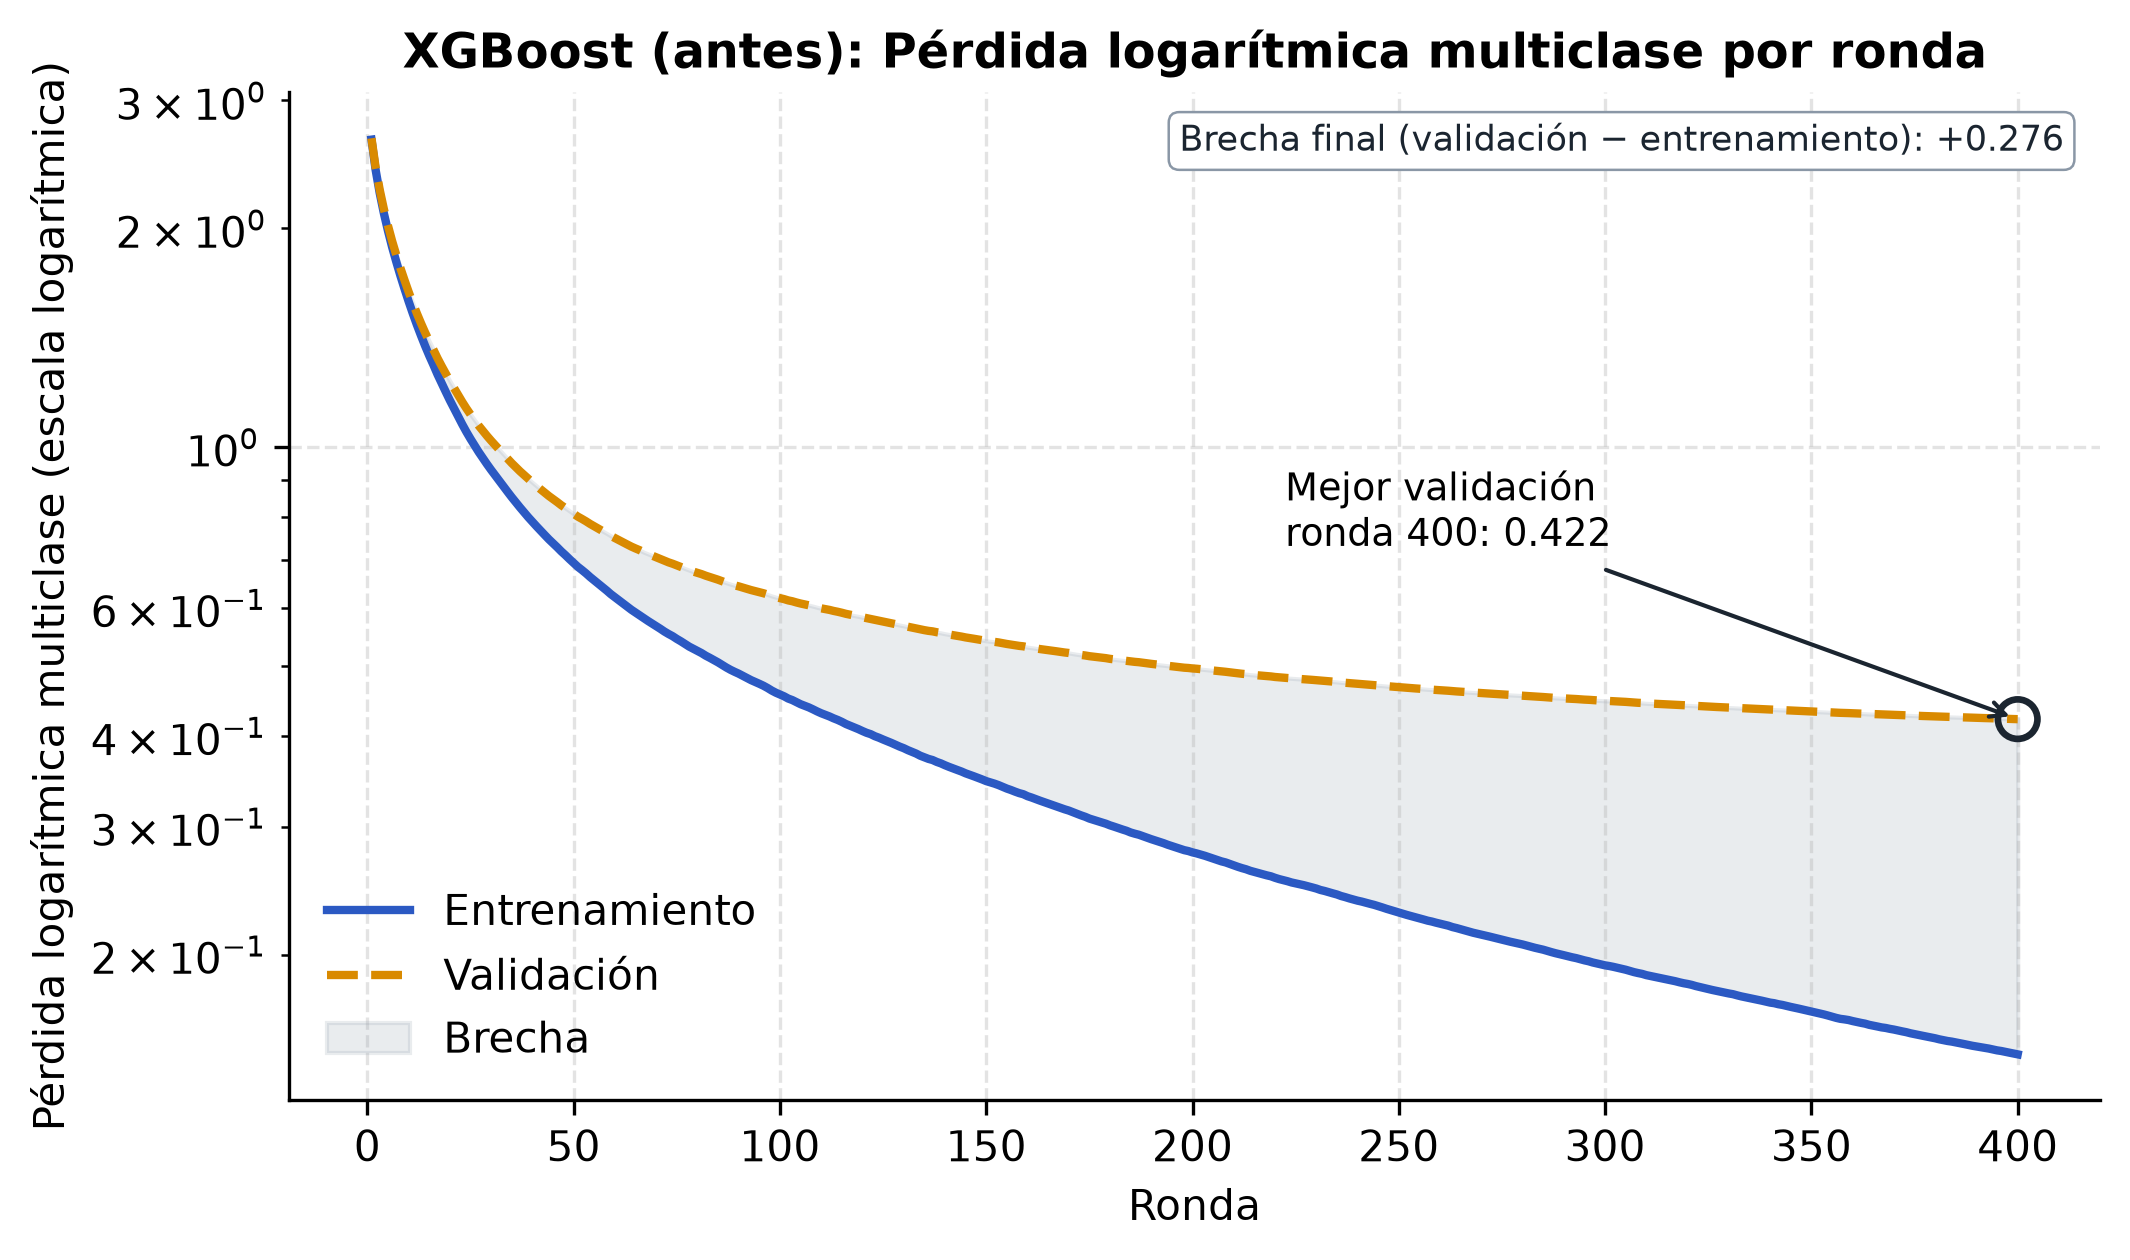

**xgboost · antes · B_f1**

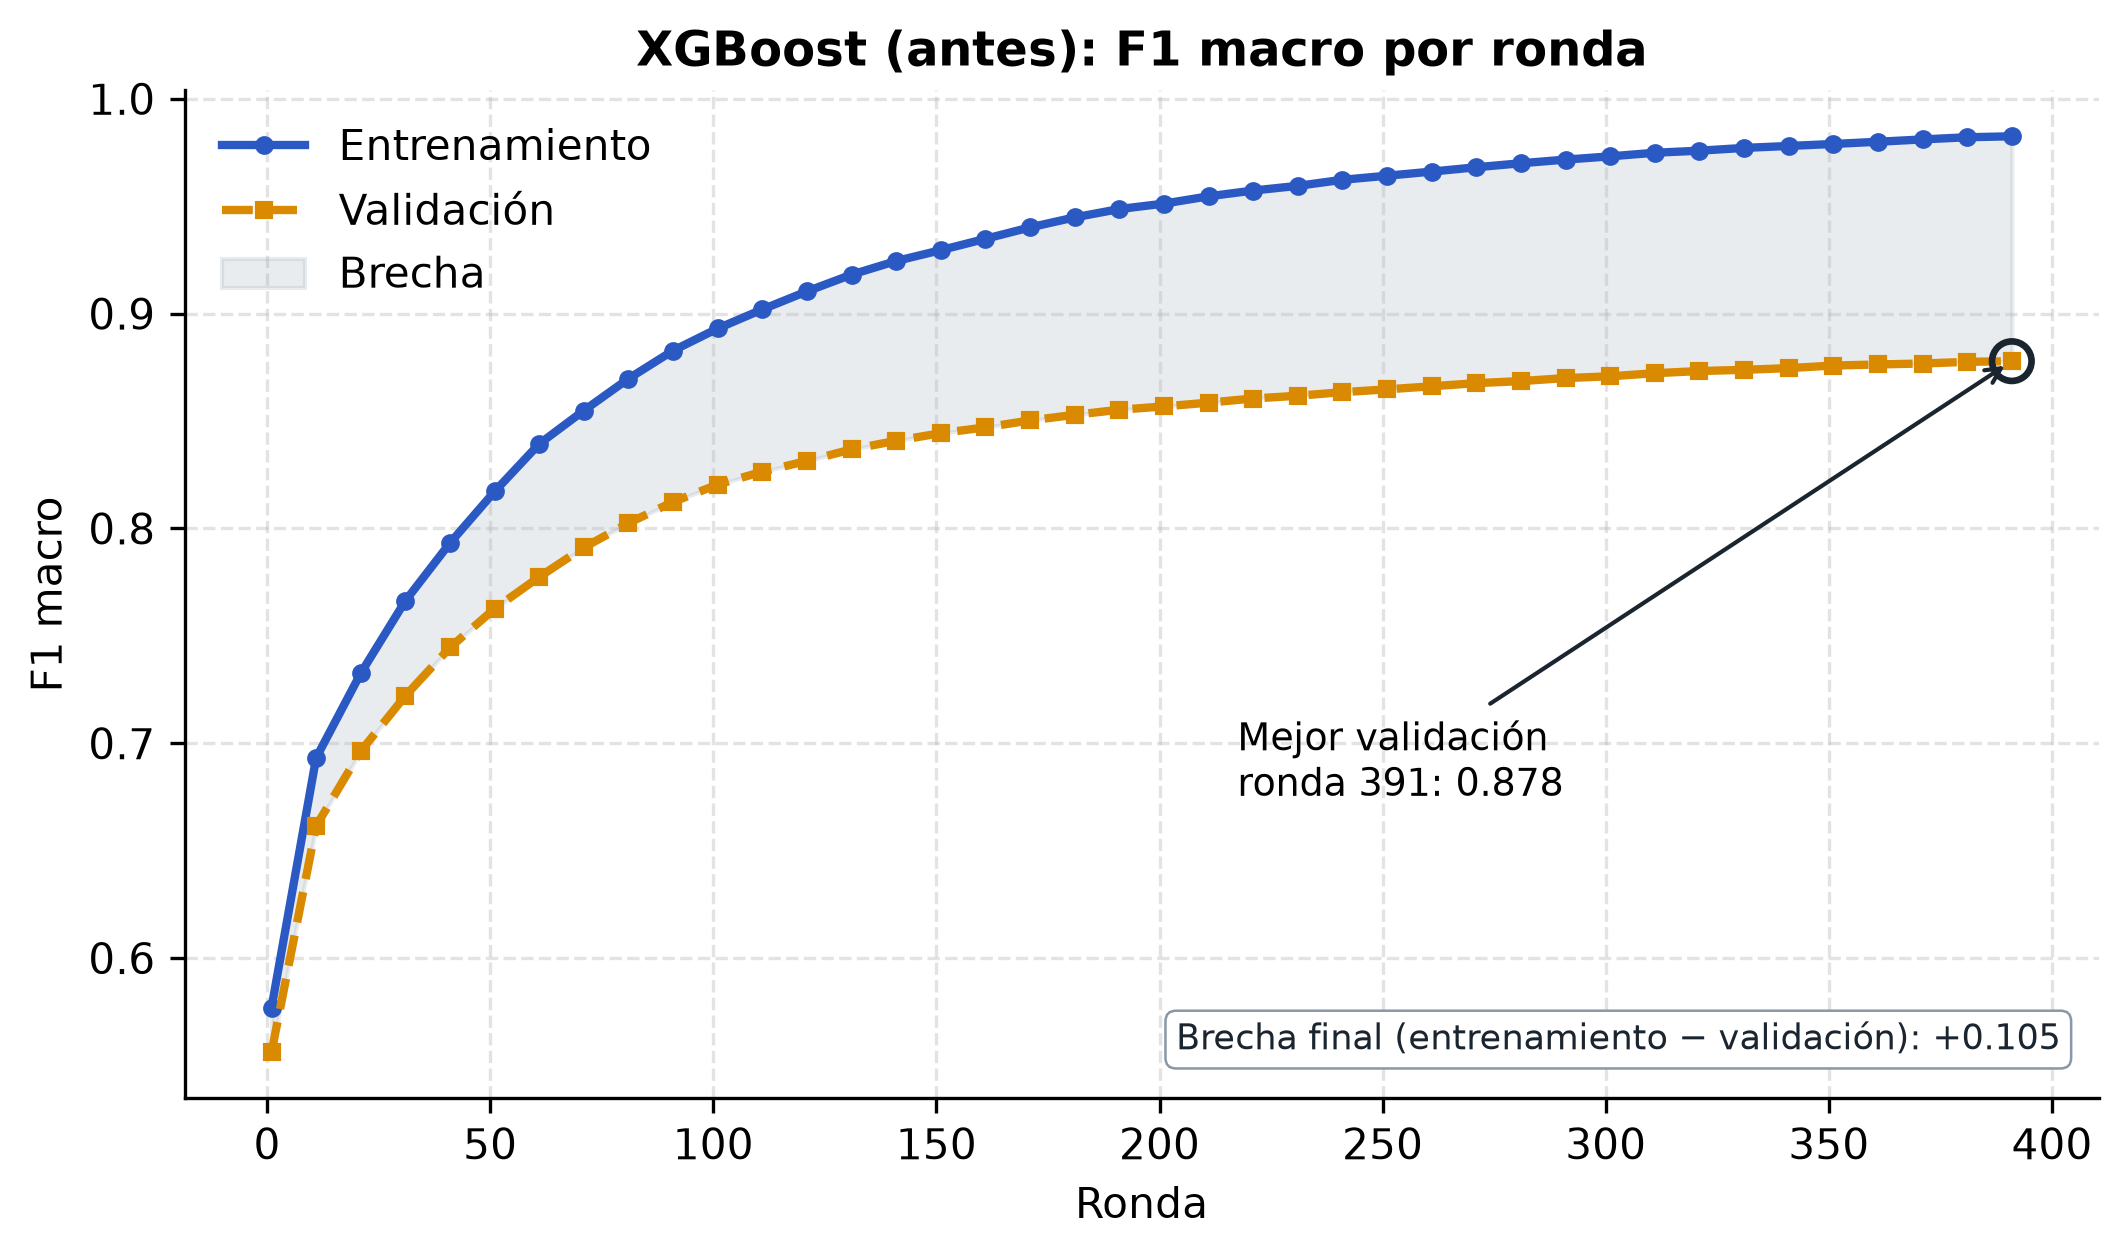

**xgboost · despues · A_perdida**

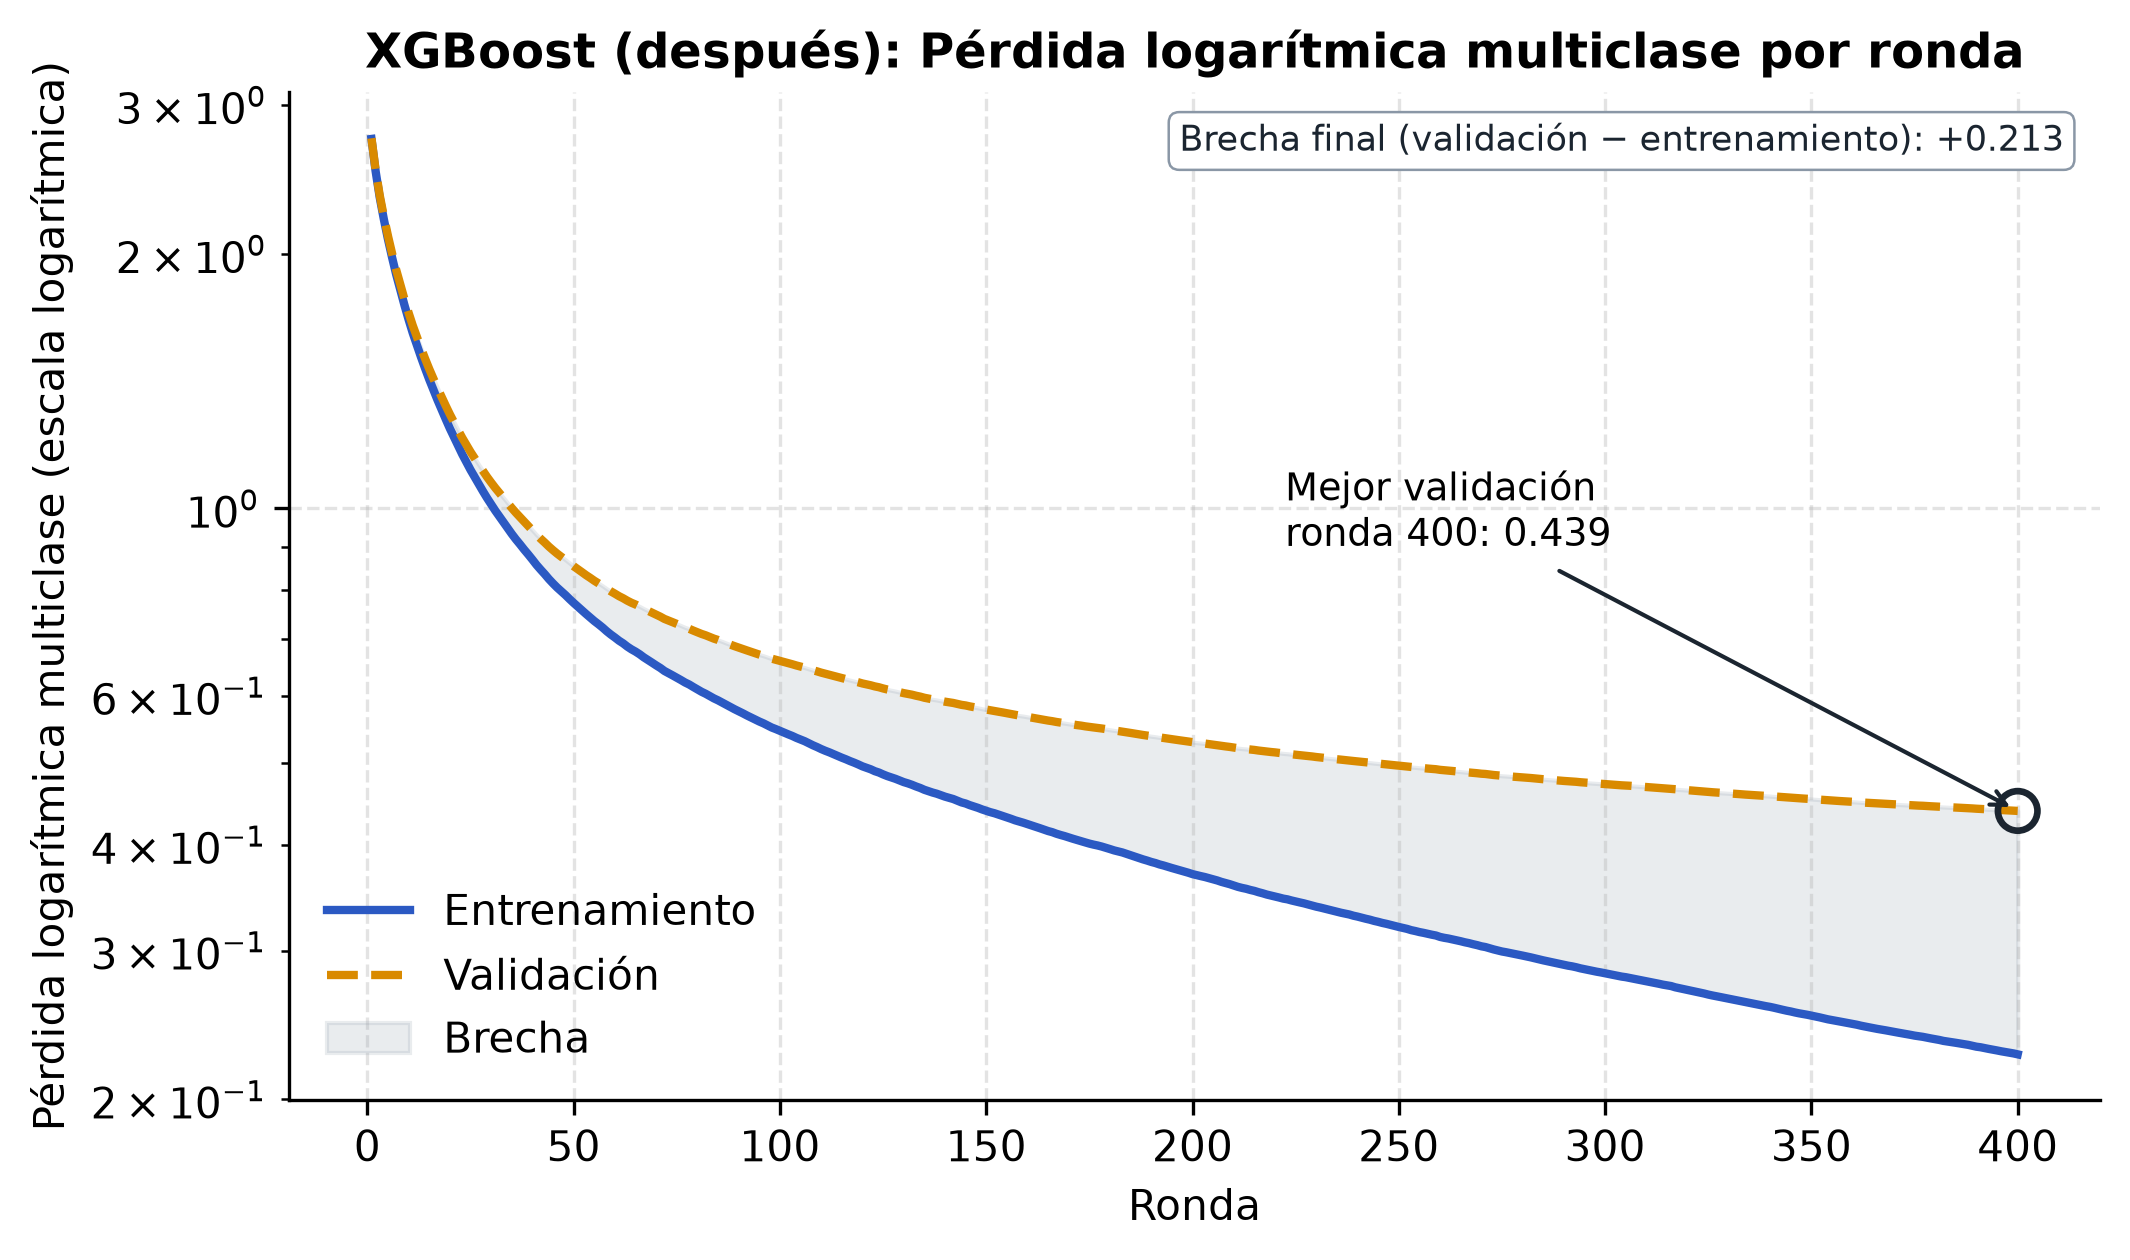

**xgboost · despues · B_f1**

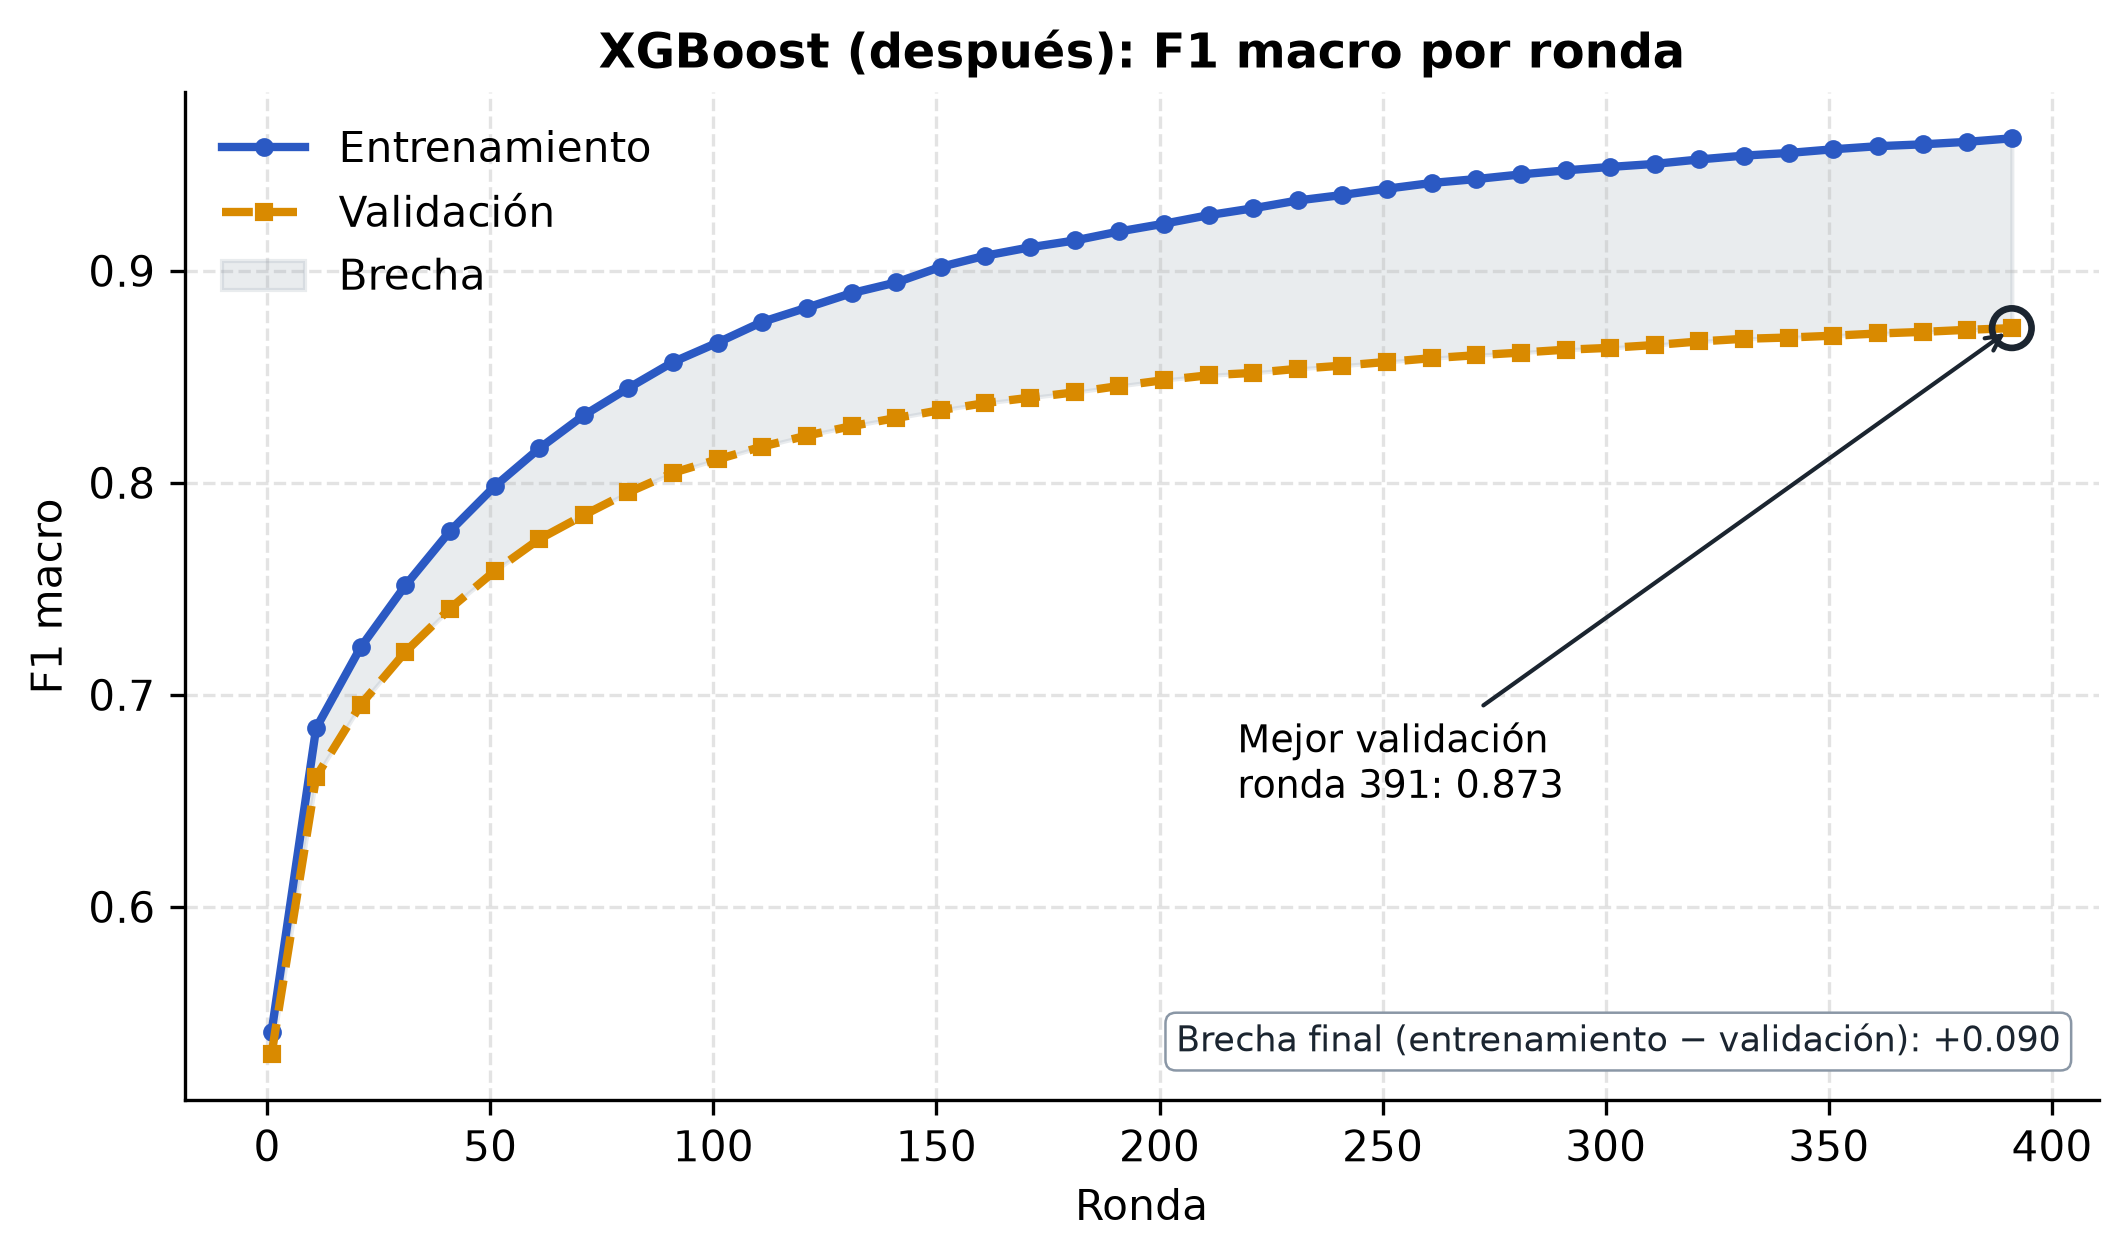

**cnn1d · antes · A_perdida**

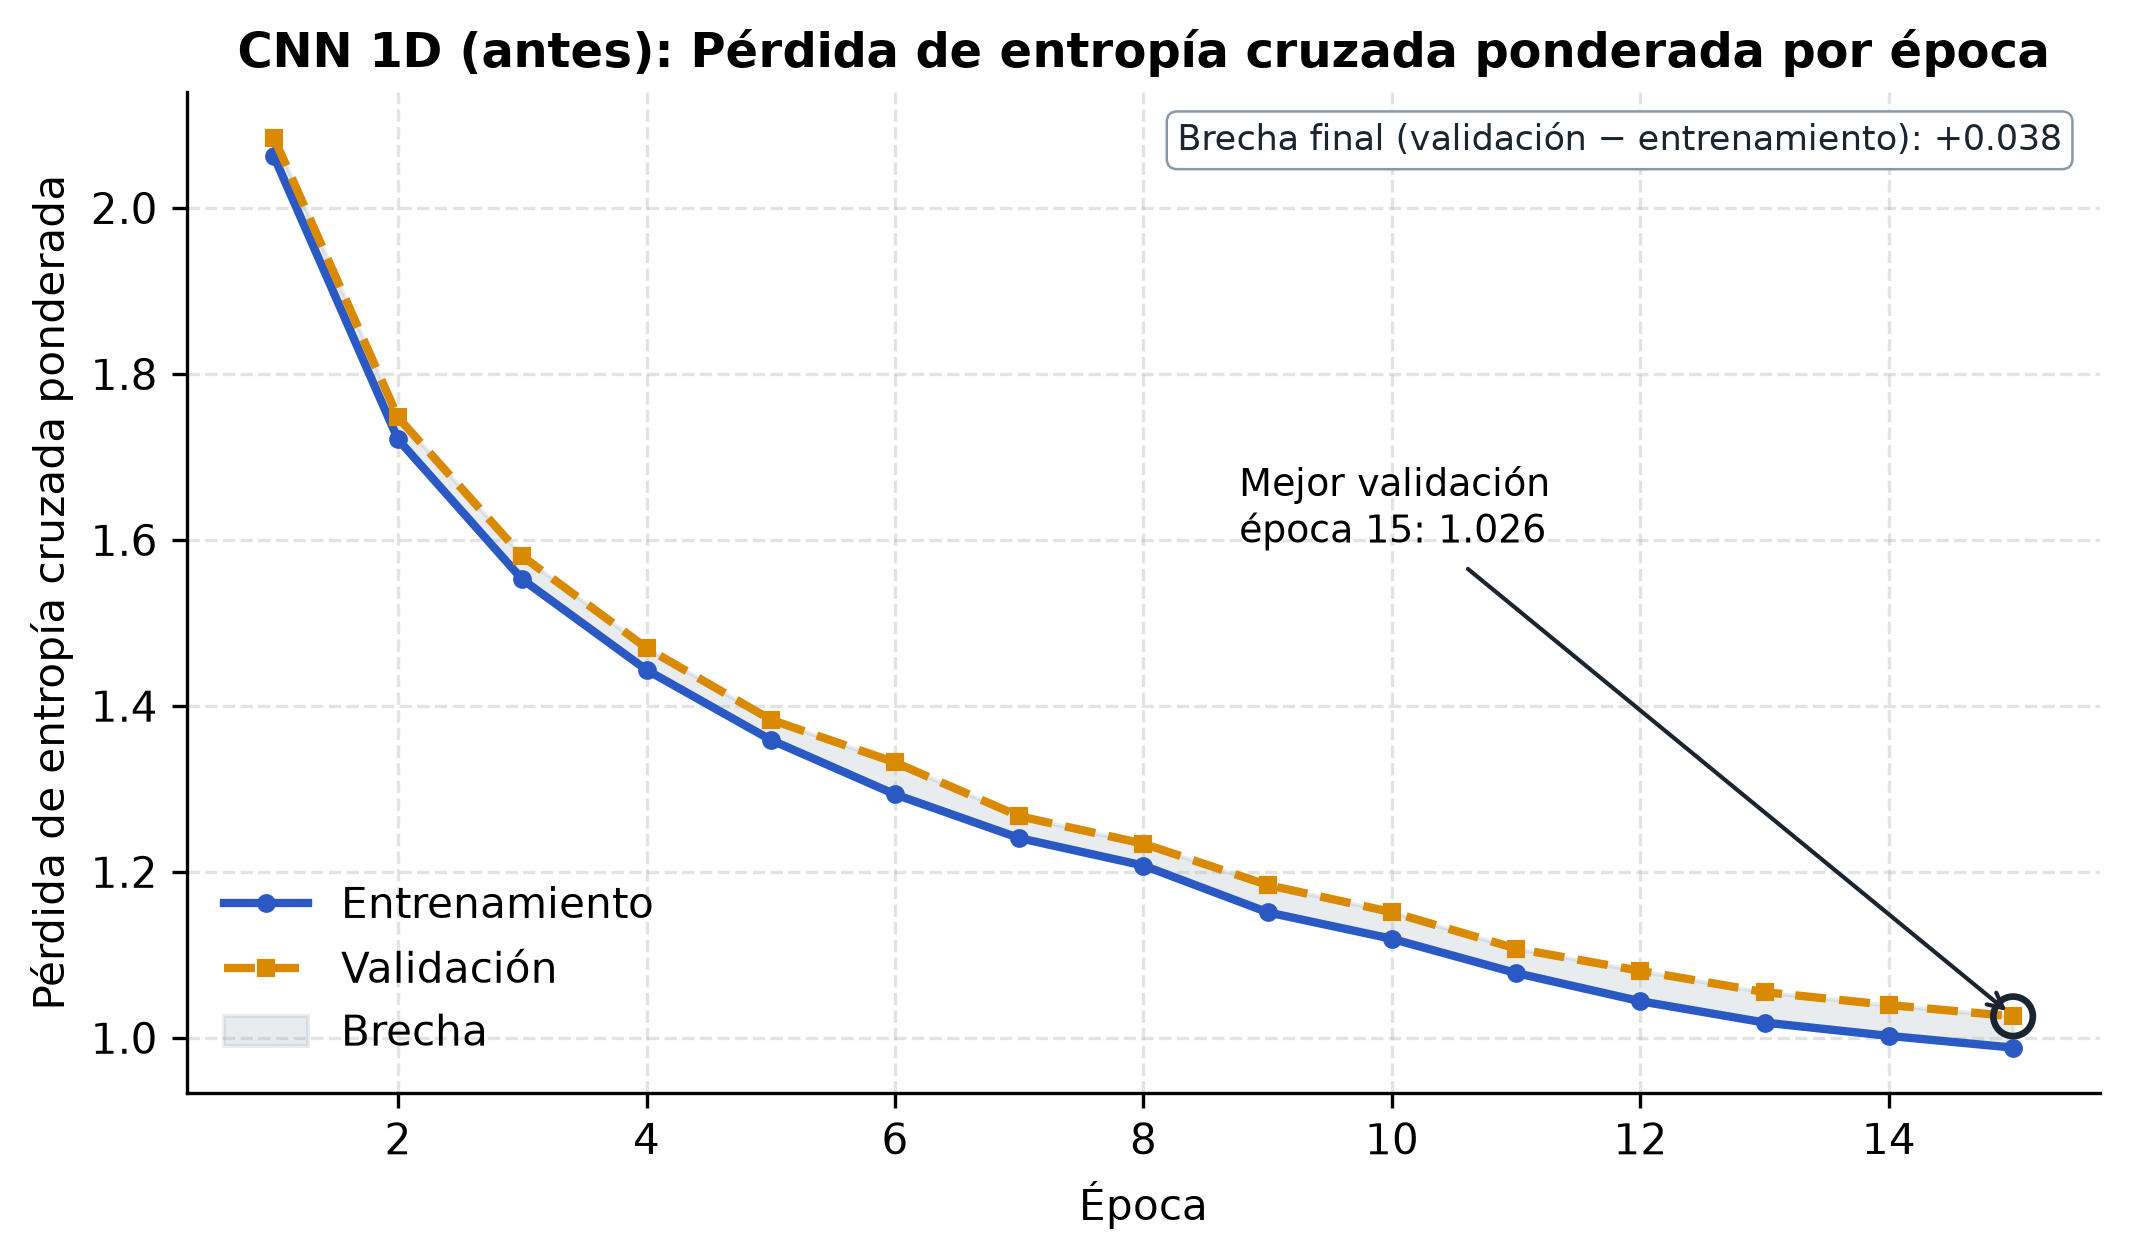

**cnn1d · antes · B_f1**

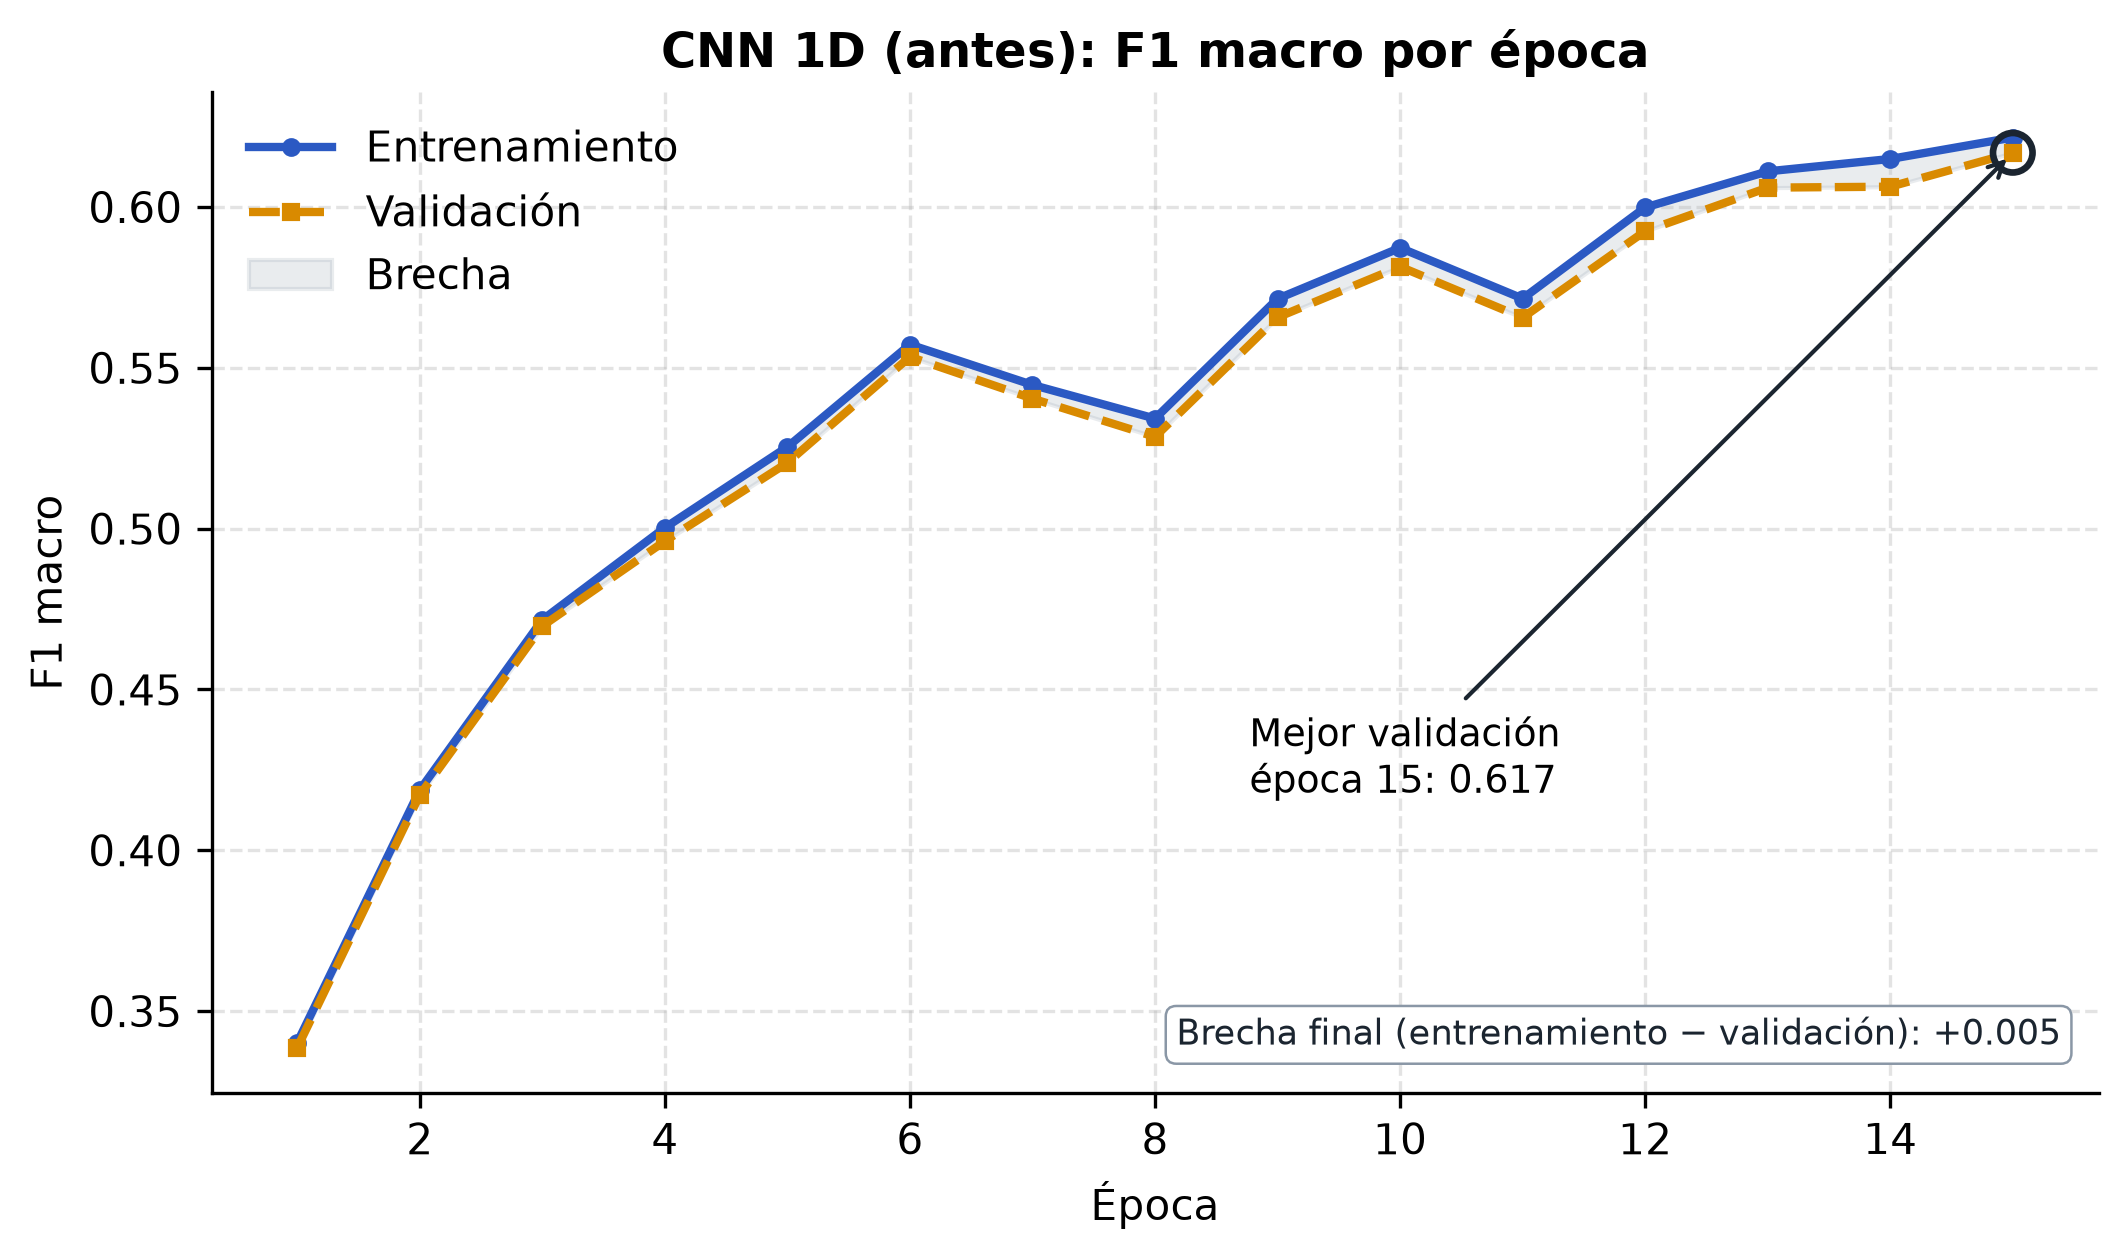

**cnn1d · despues · A_perdida**

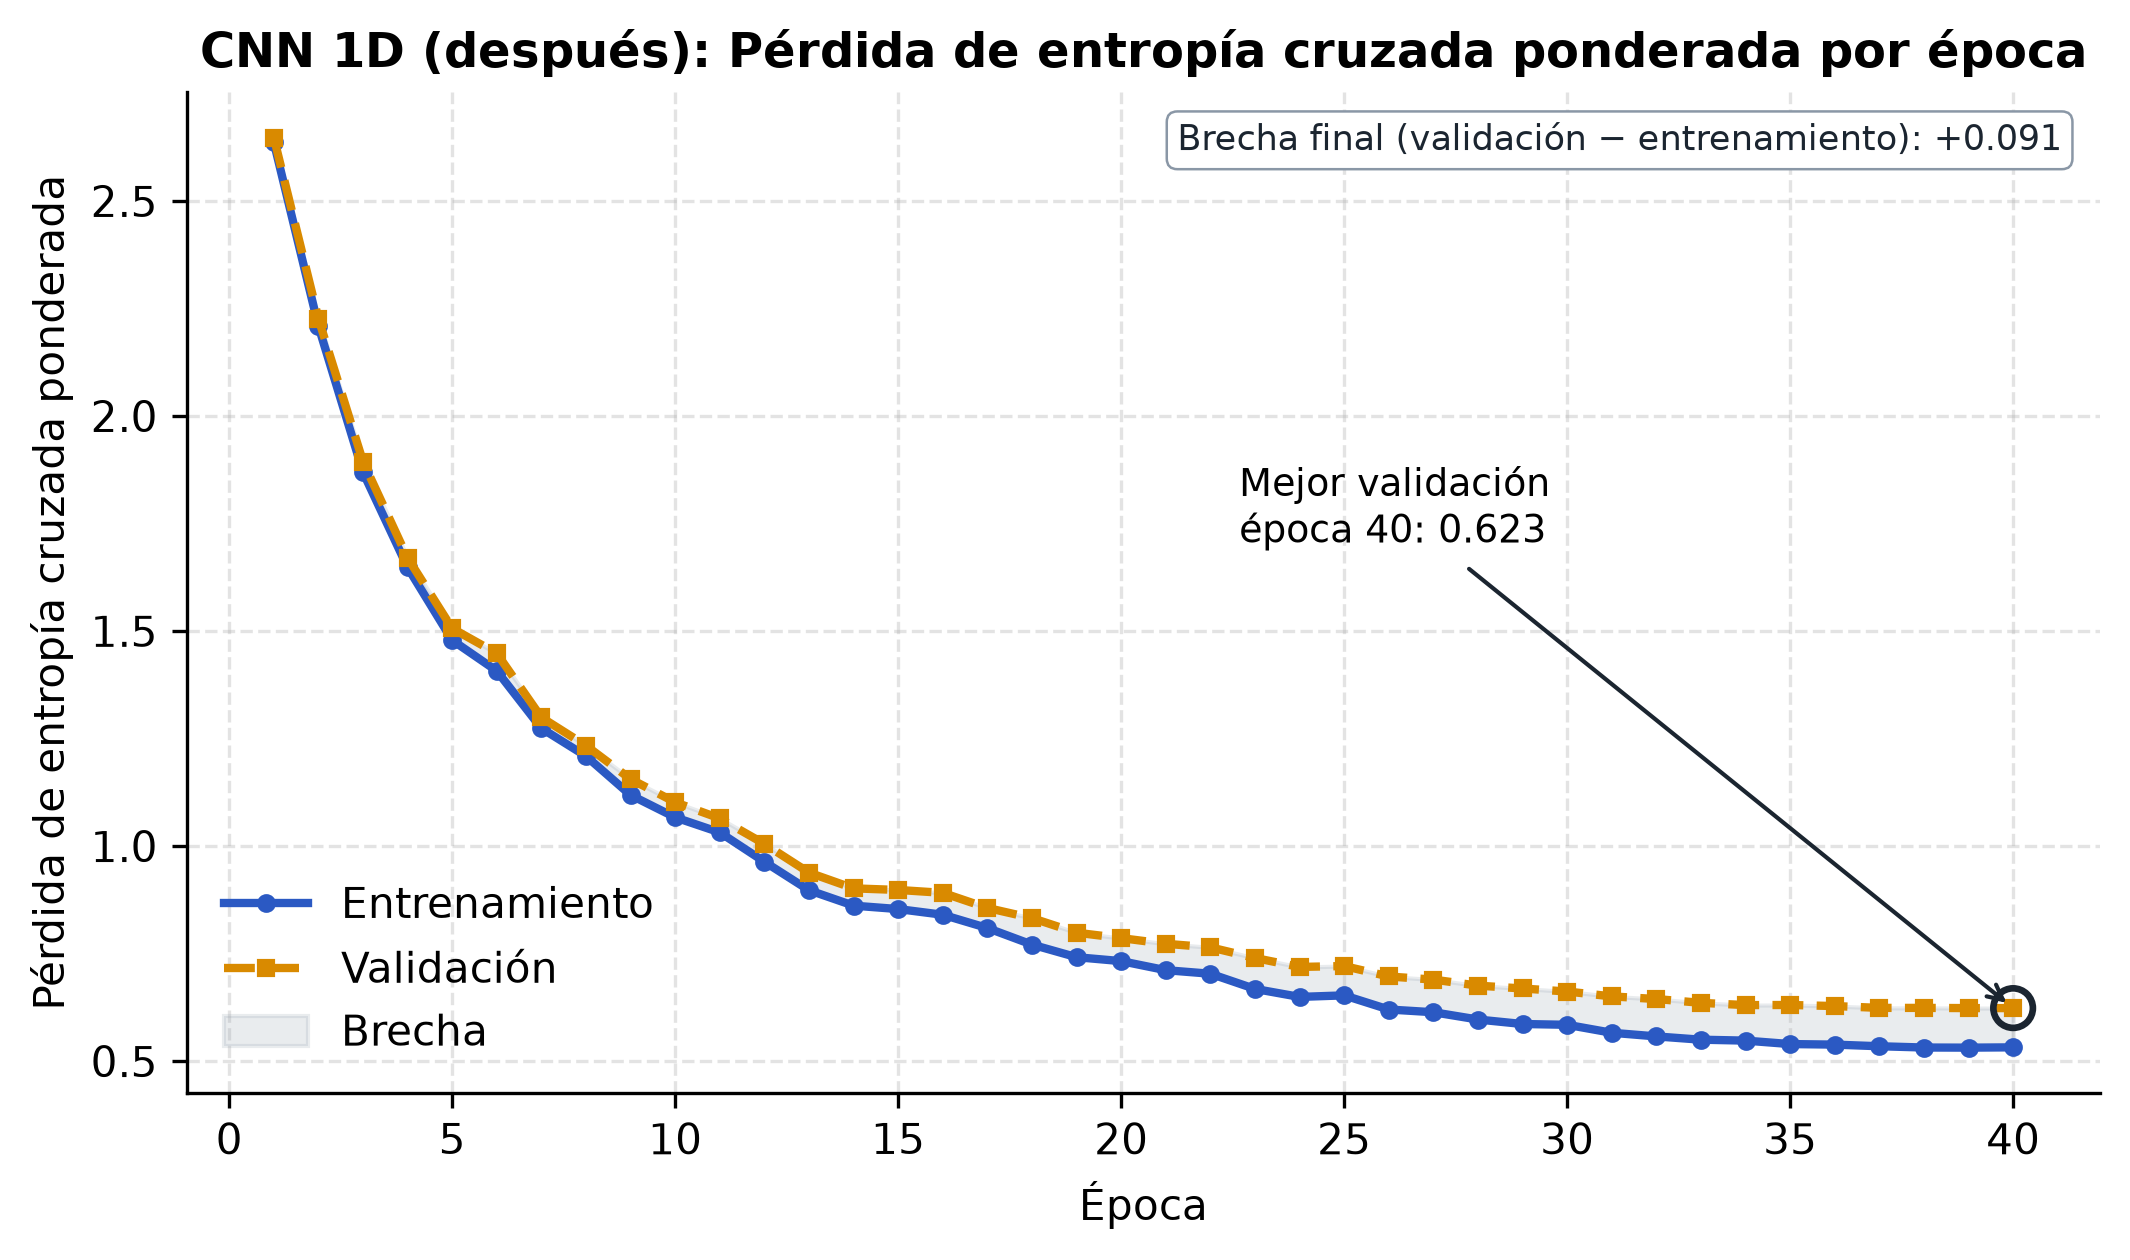

**cnn1d · despues · B_f1**

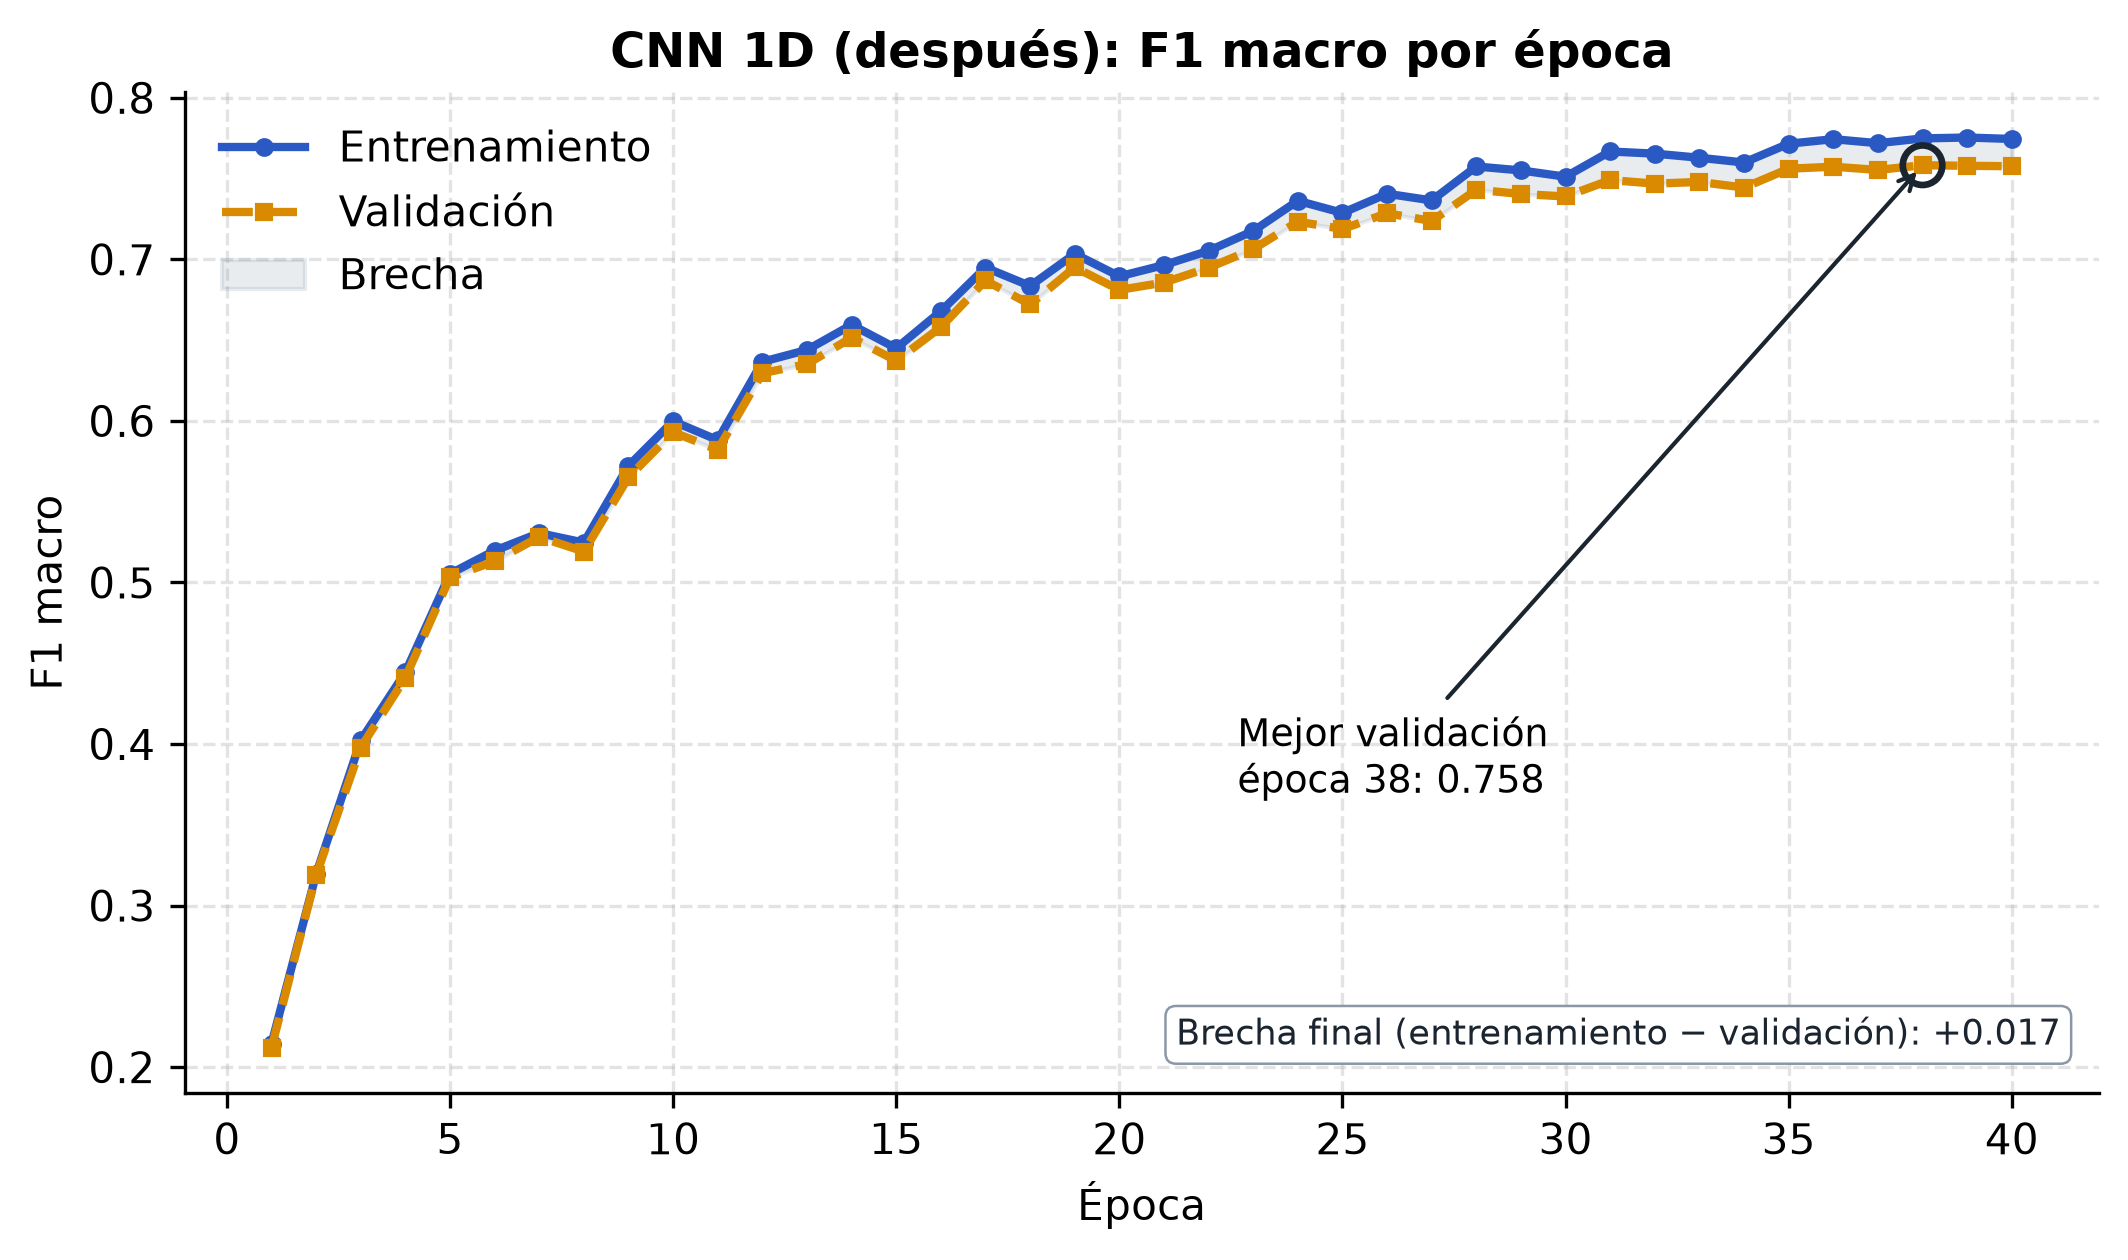

**transformer · antes · A_perdida**

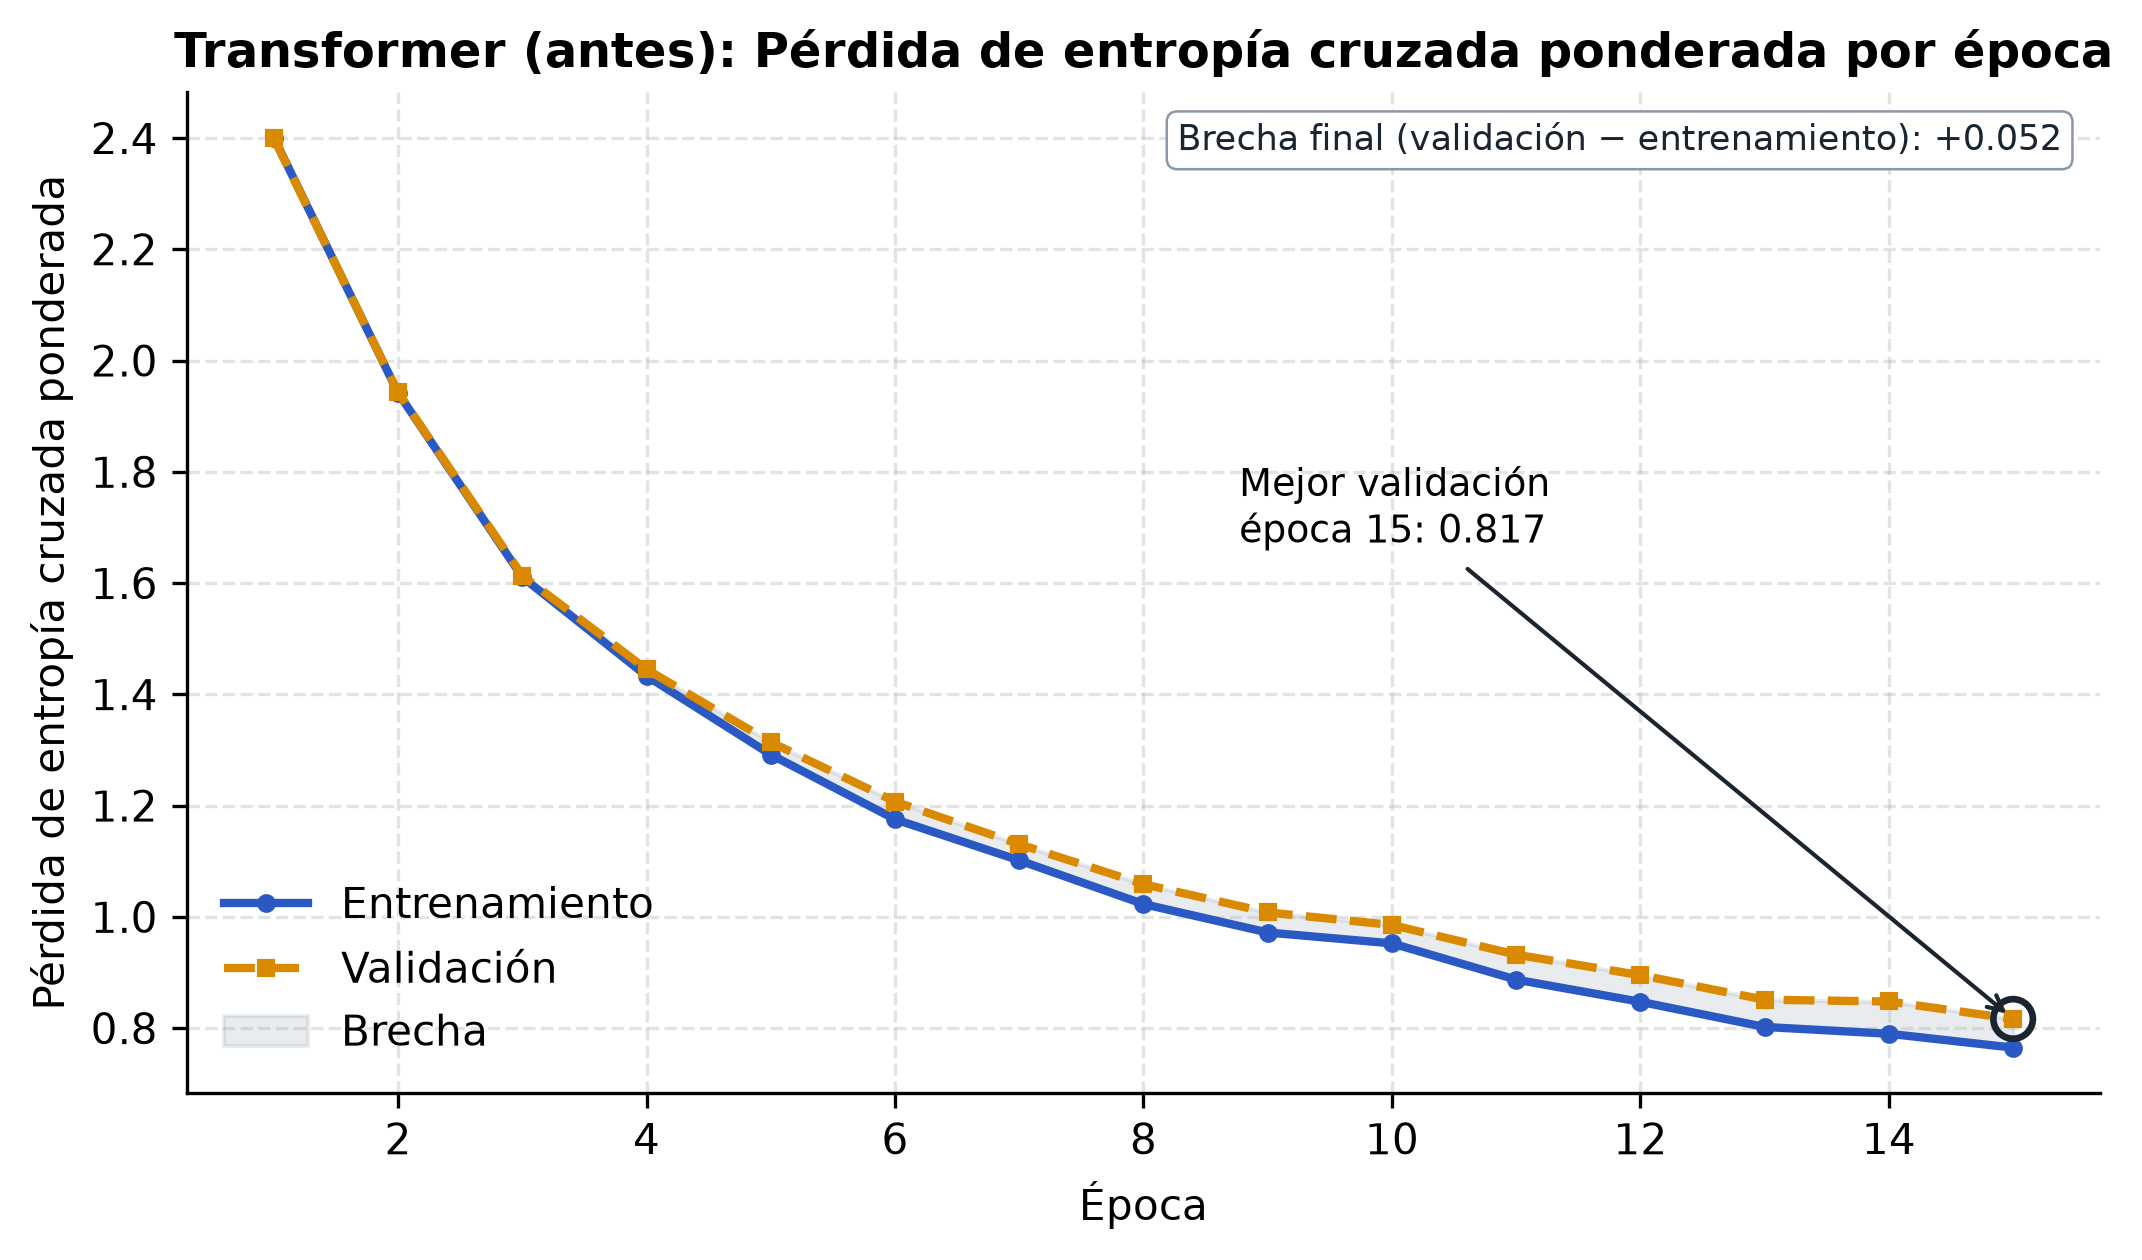

**transformer · antes · B_f1**

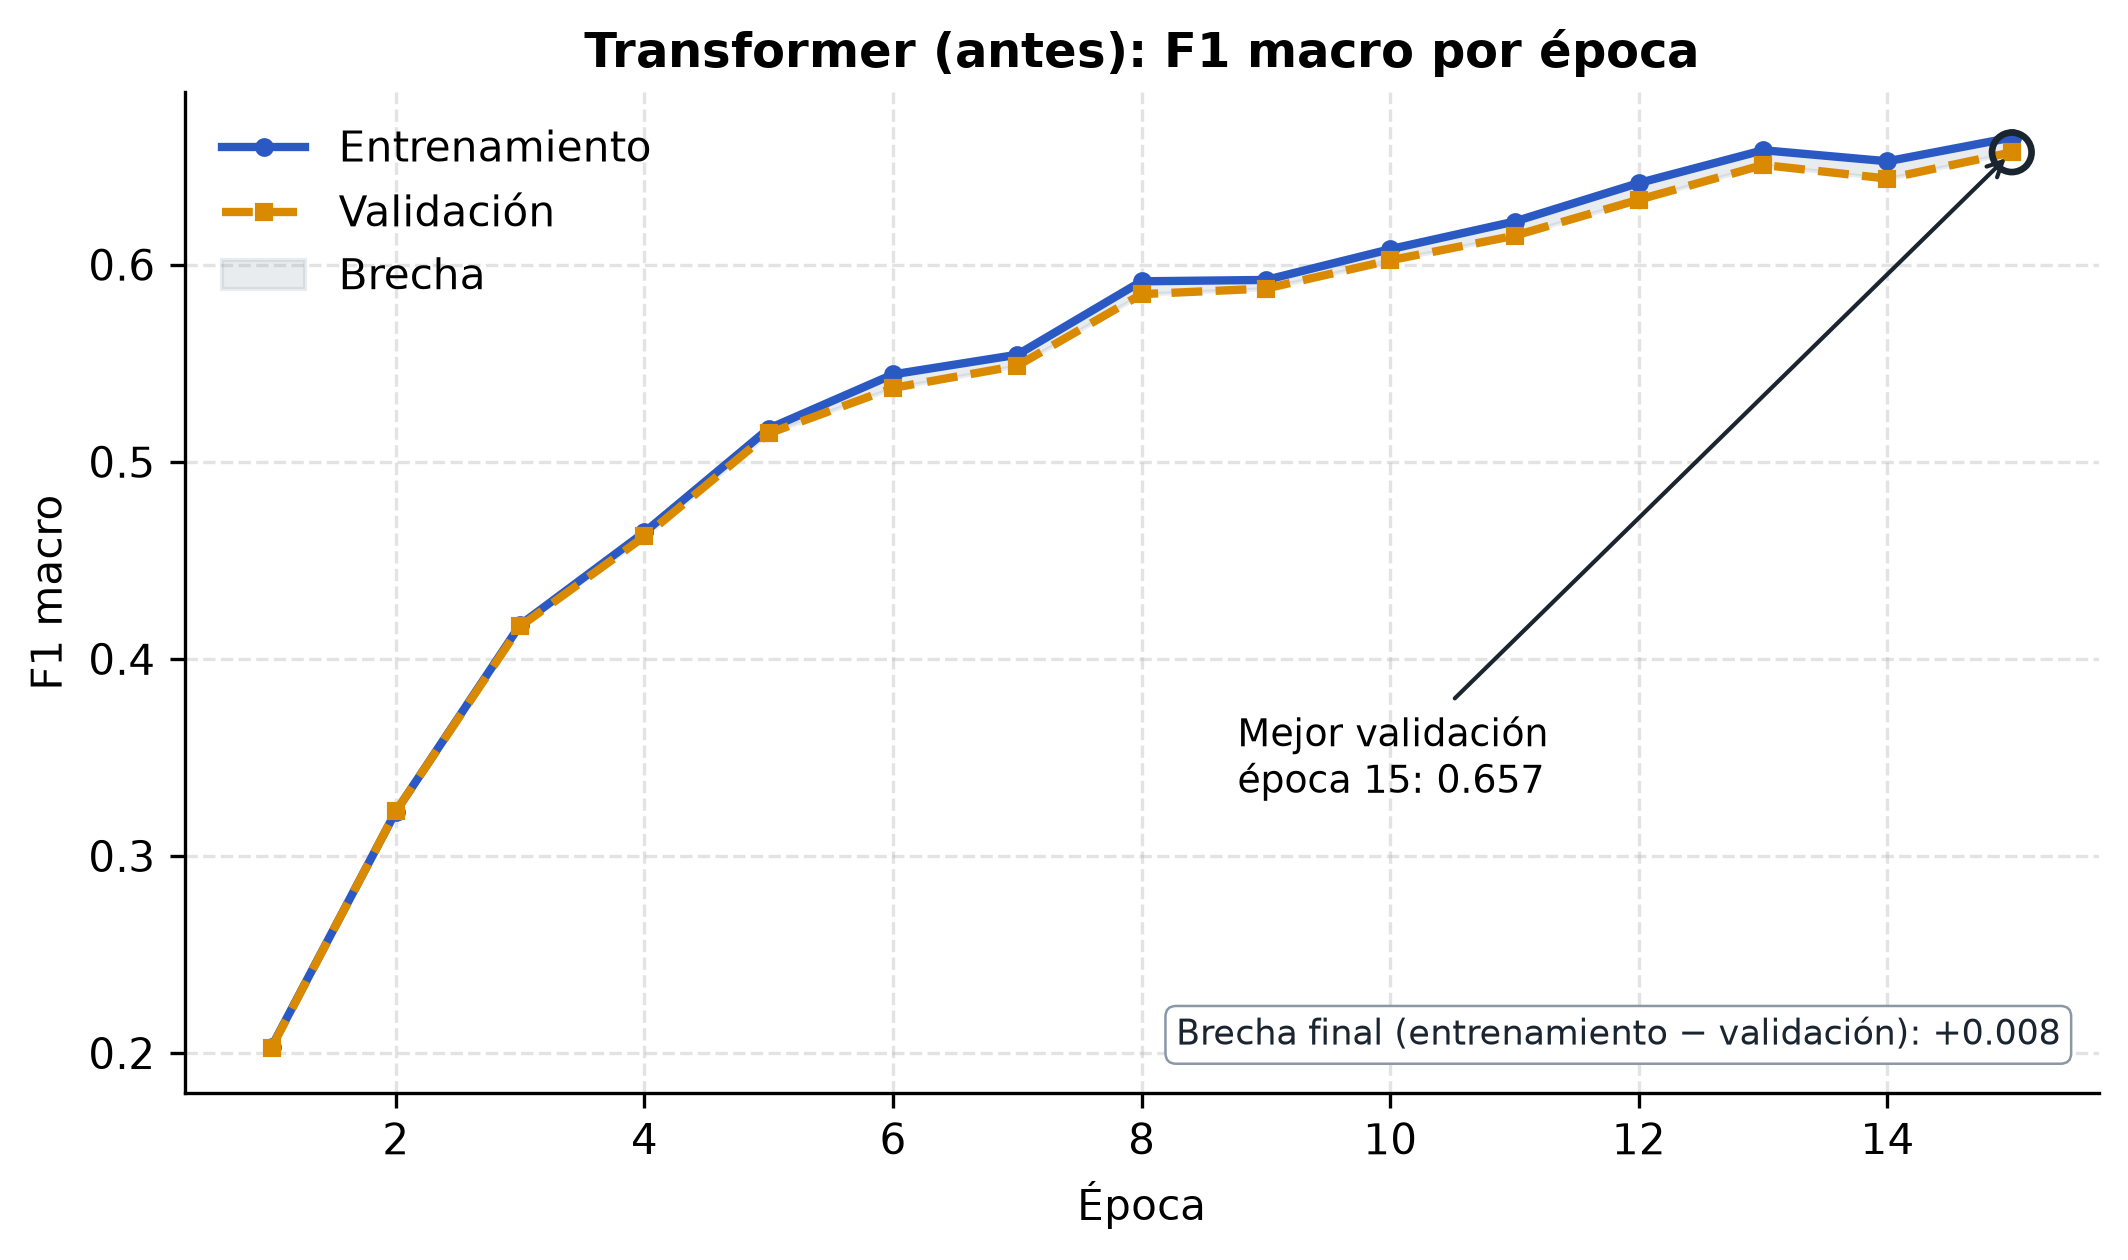

**transformer · despues · A_perdida**

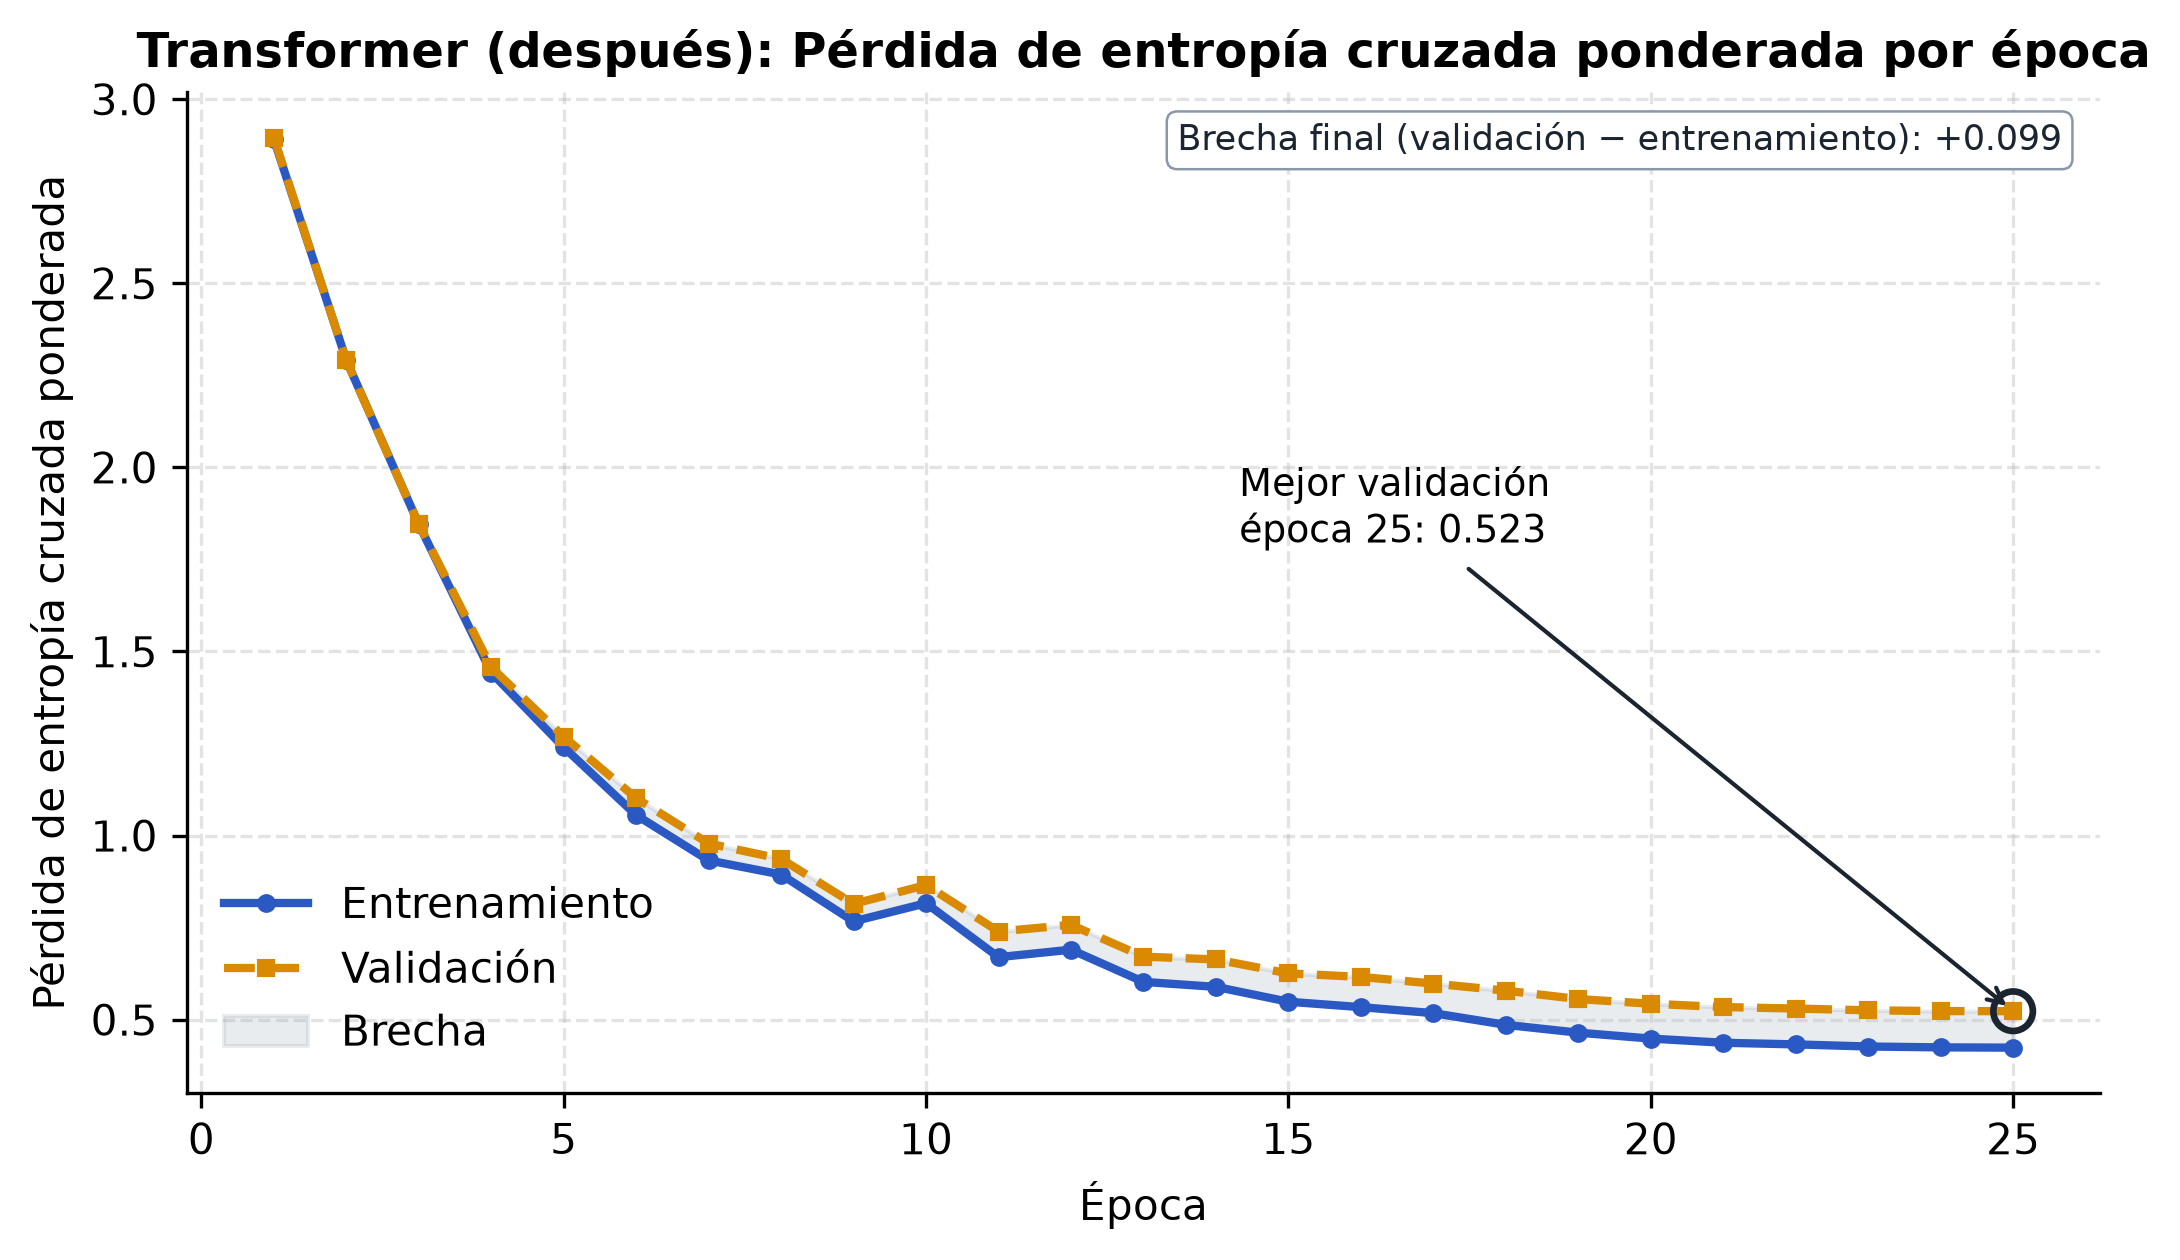

**transformer · despues · B_f1**

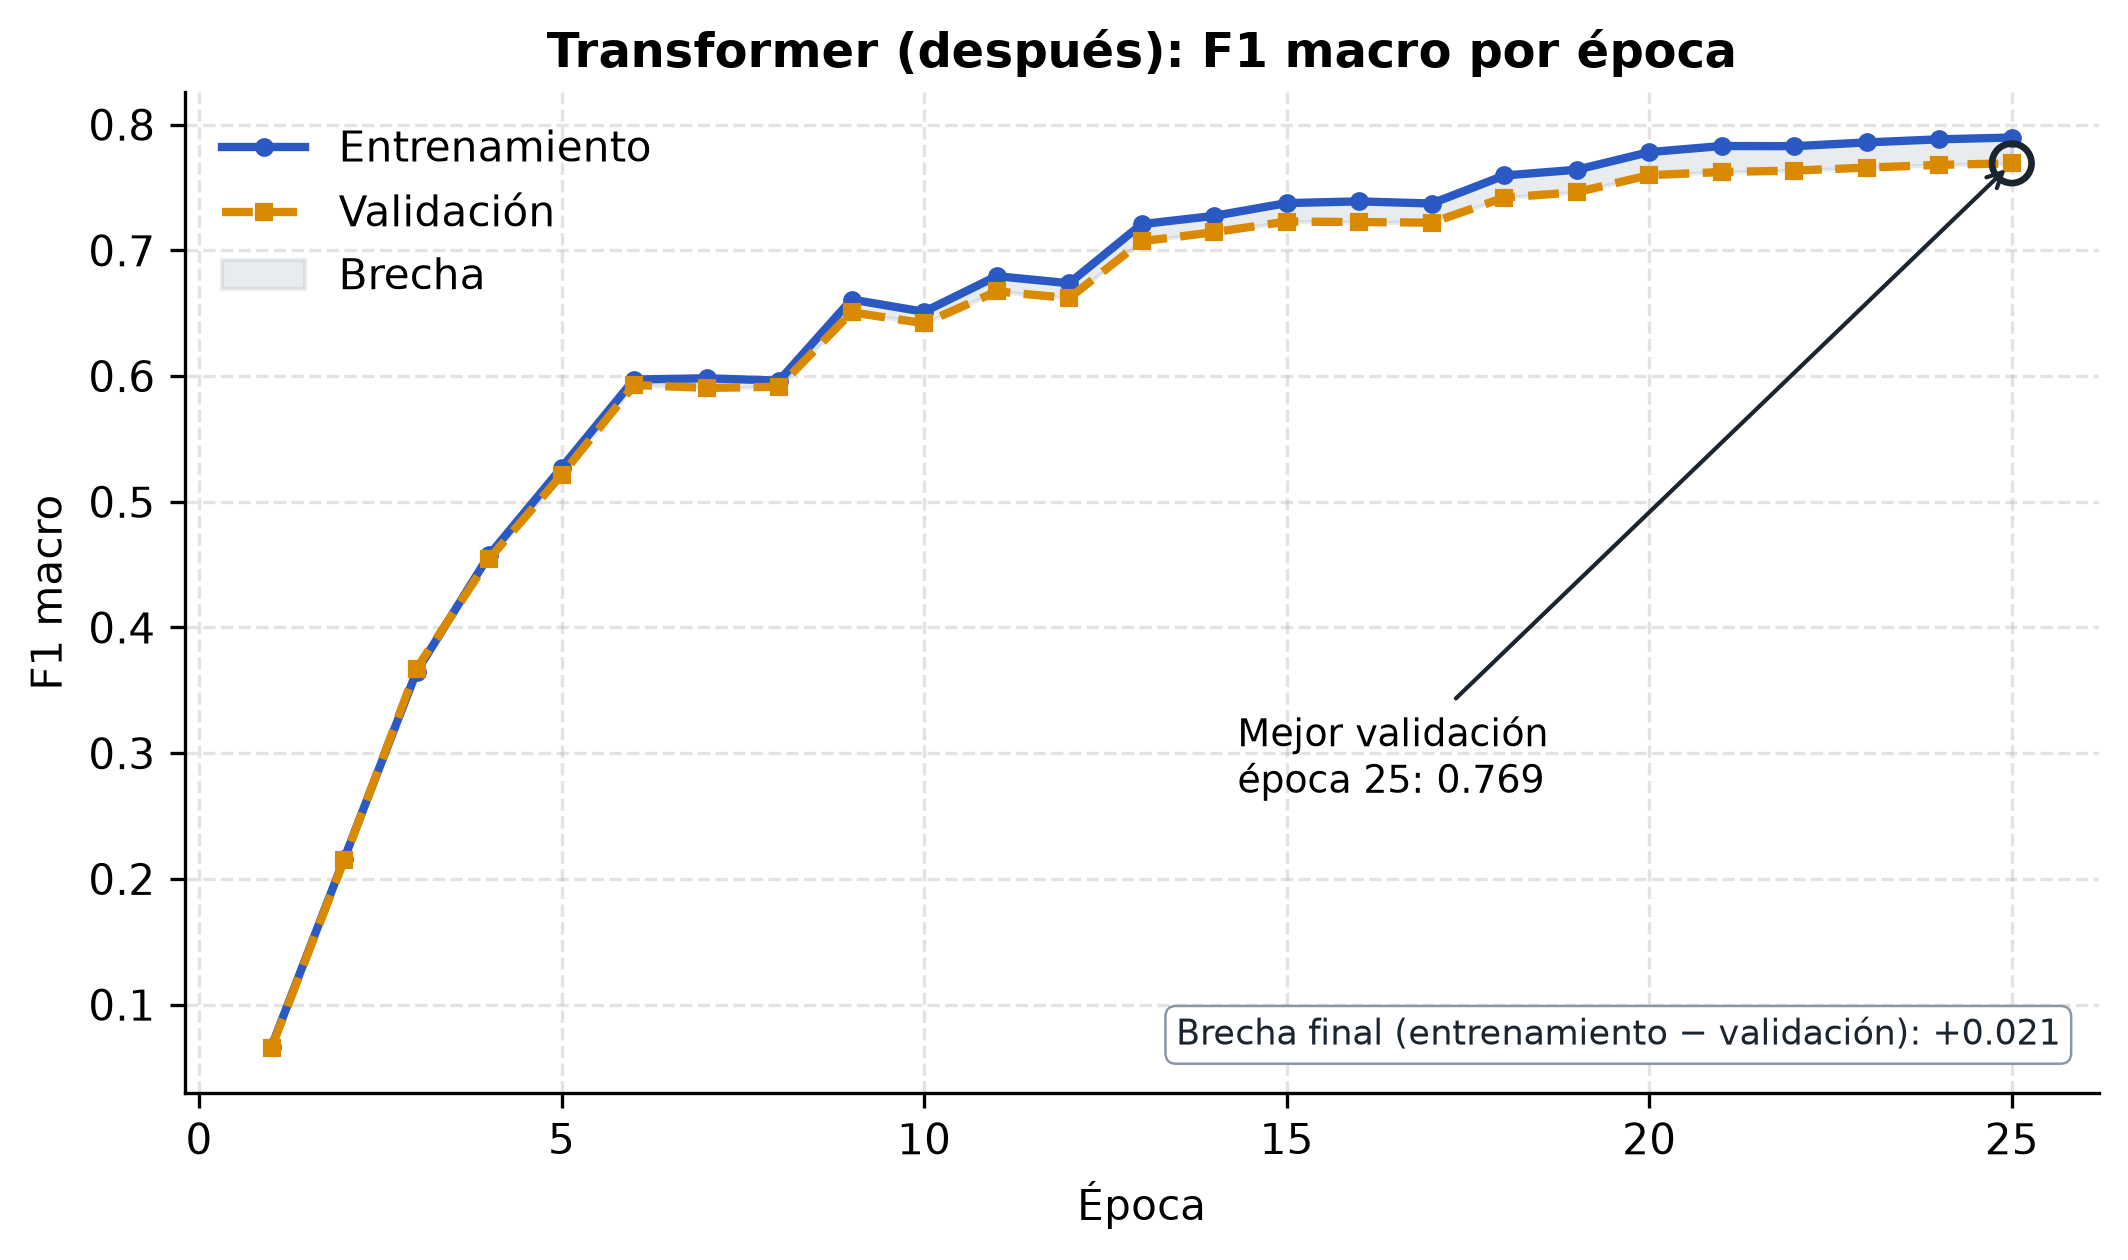

In [6]:
for m in ("xgboost", "cnn1d", "transformer"):
    for momento in ("antes", "despues"):
        for f in ("A_perdida.png", "B_f1.png"):
            ruta = R / m / momento / f
            if ruta.exists():
                display(Markdown(f"**{m} · {momento} · {f[:-4]}**")); display(Image(filename=str(ruta), width=640))

**Random Forest · C_curva_por_tamano**

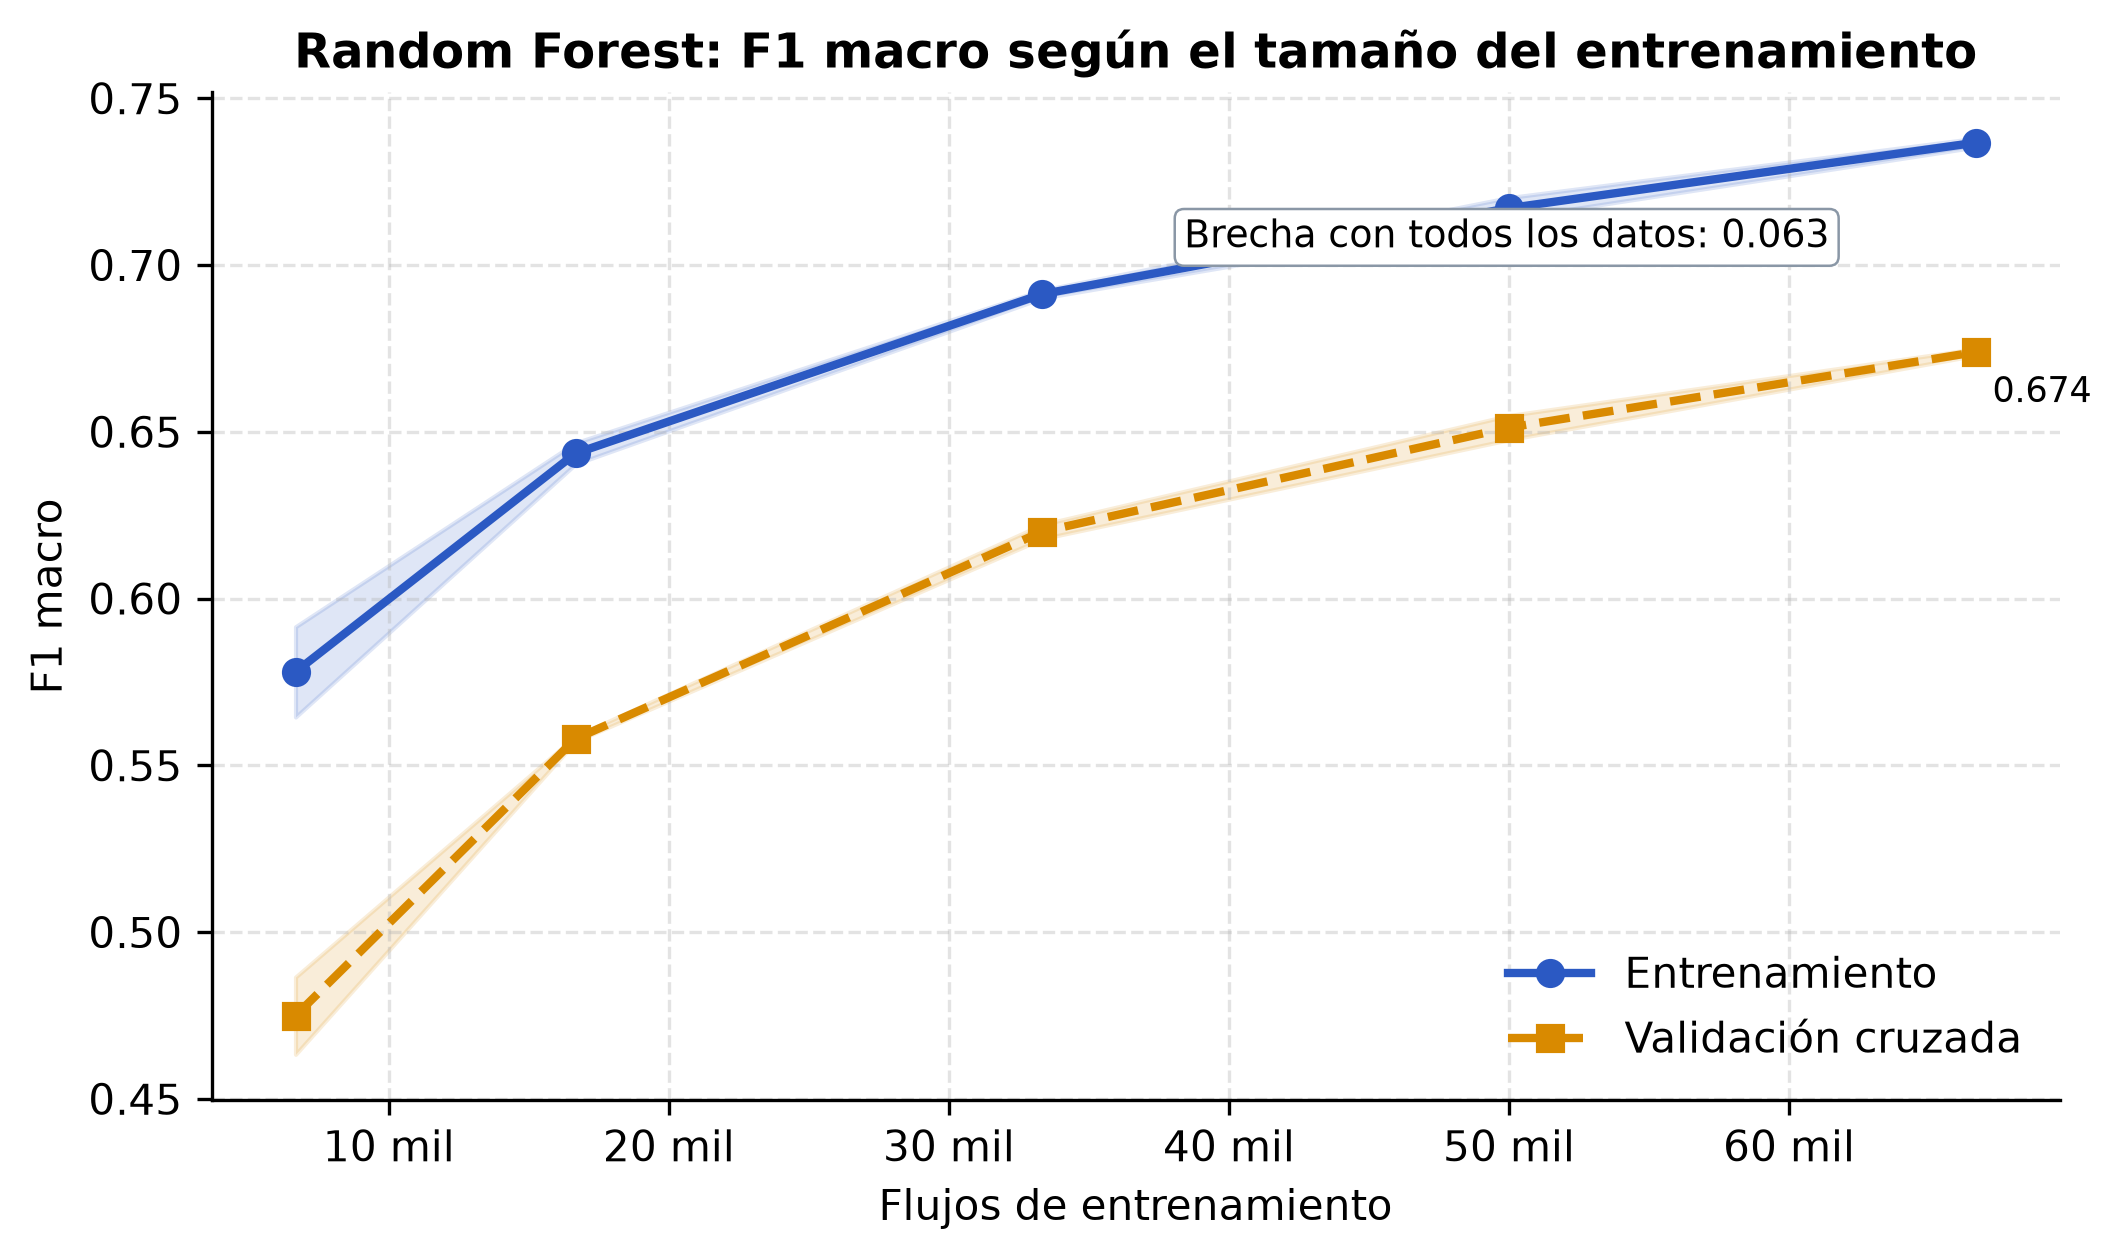

**Random Forest · D_curva_min_samples_leaf**

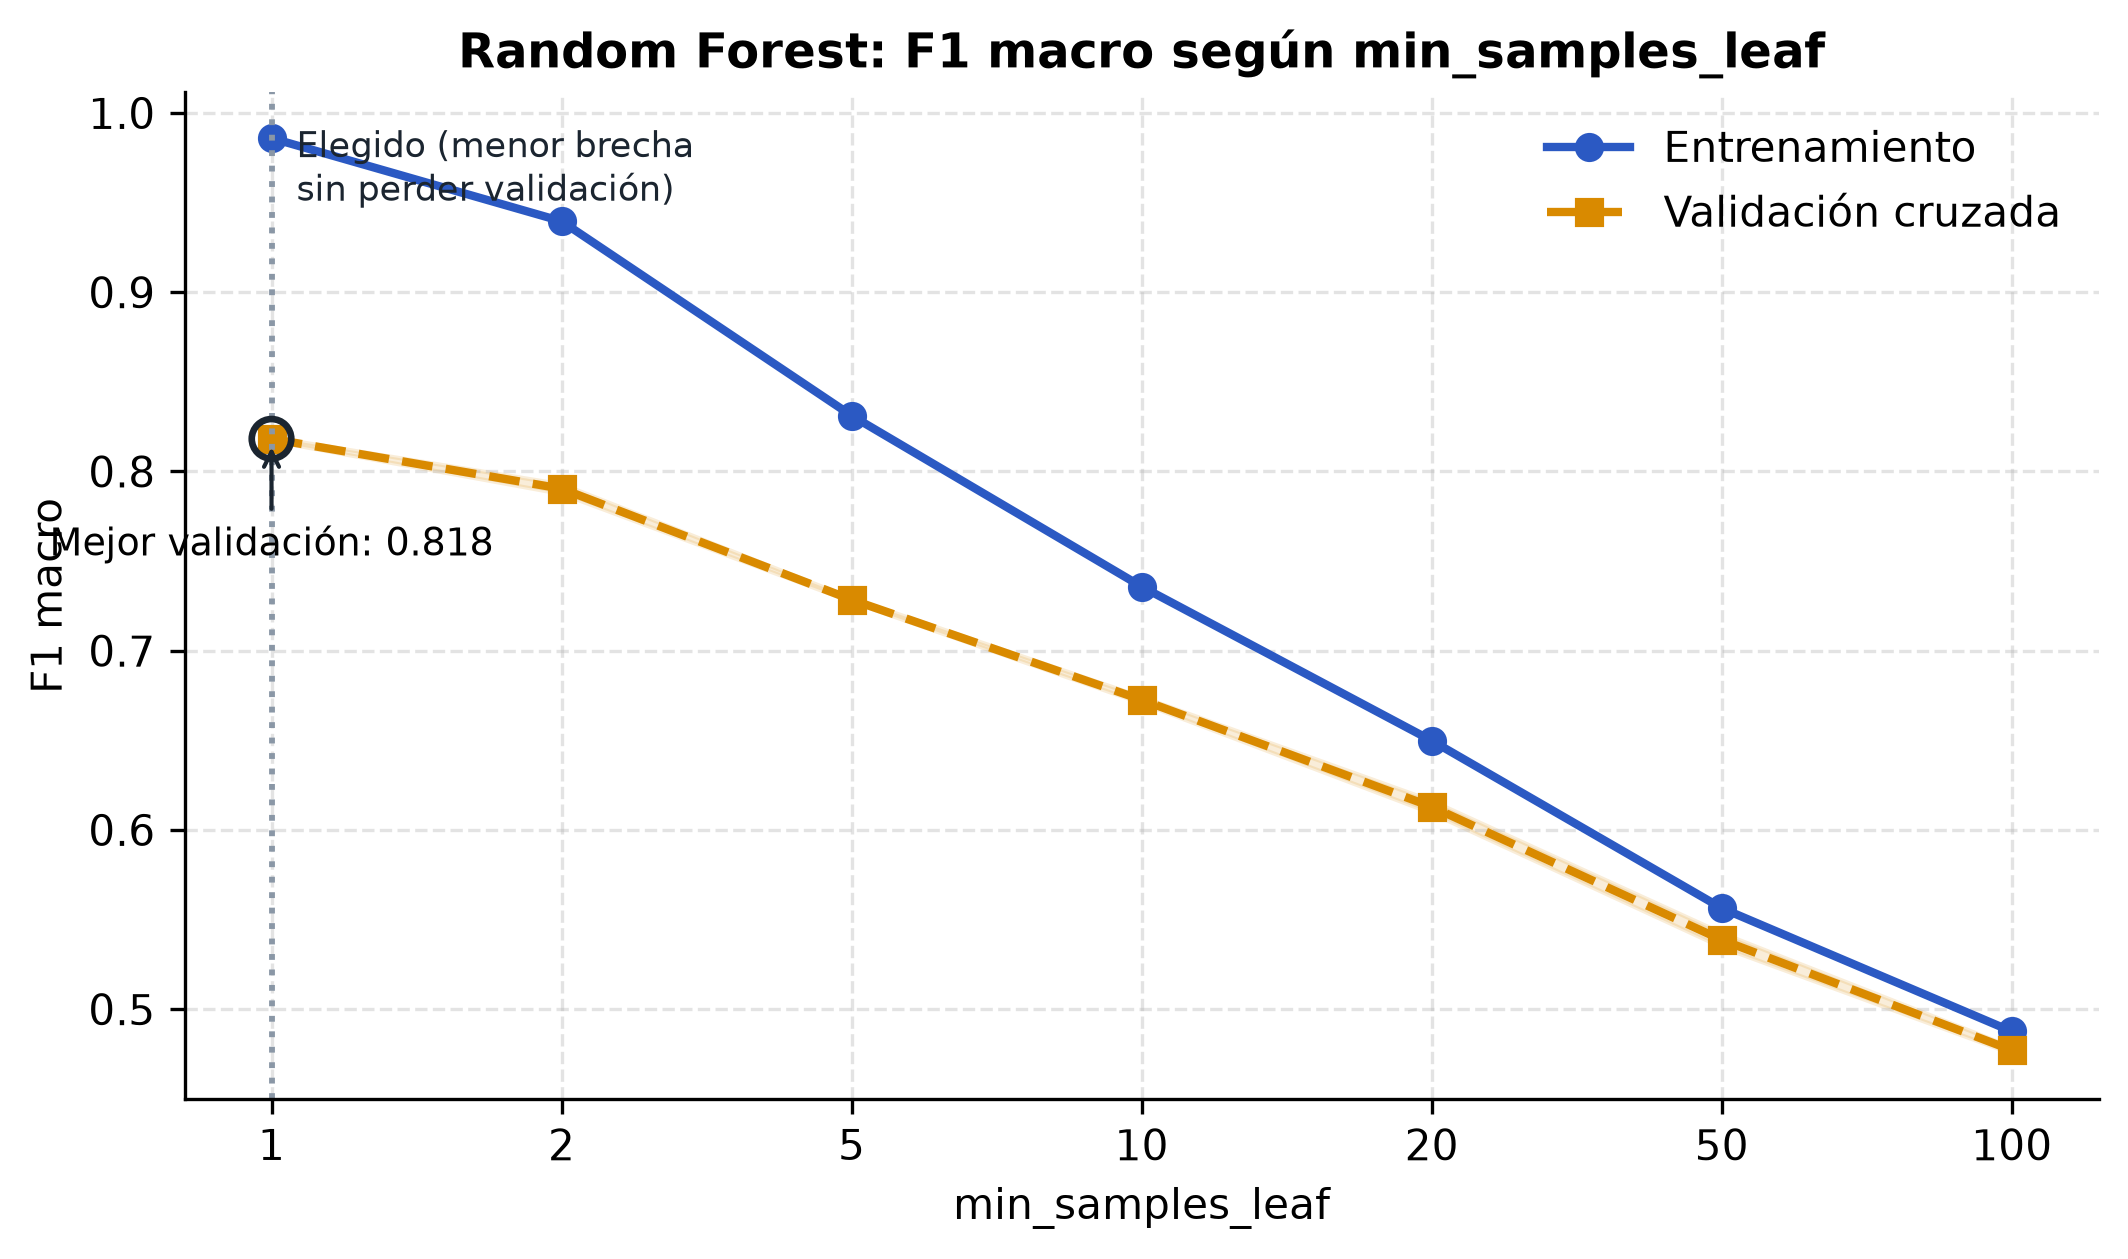

**Random Forest · D_curva_max_depth**

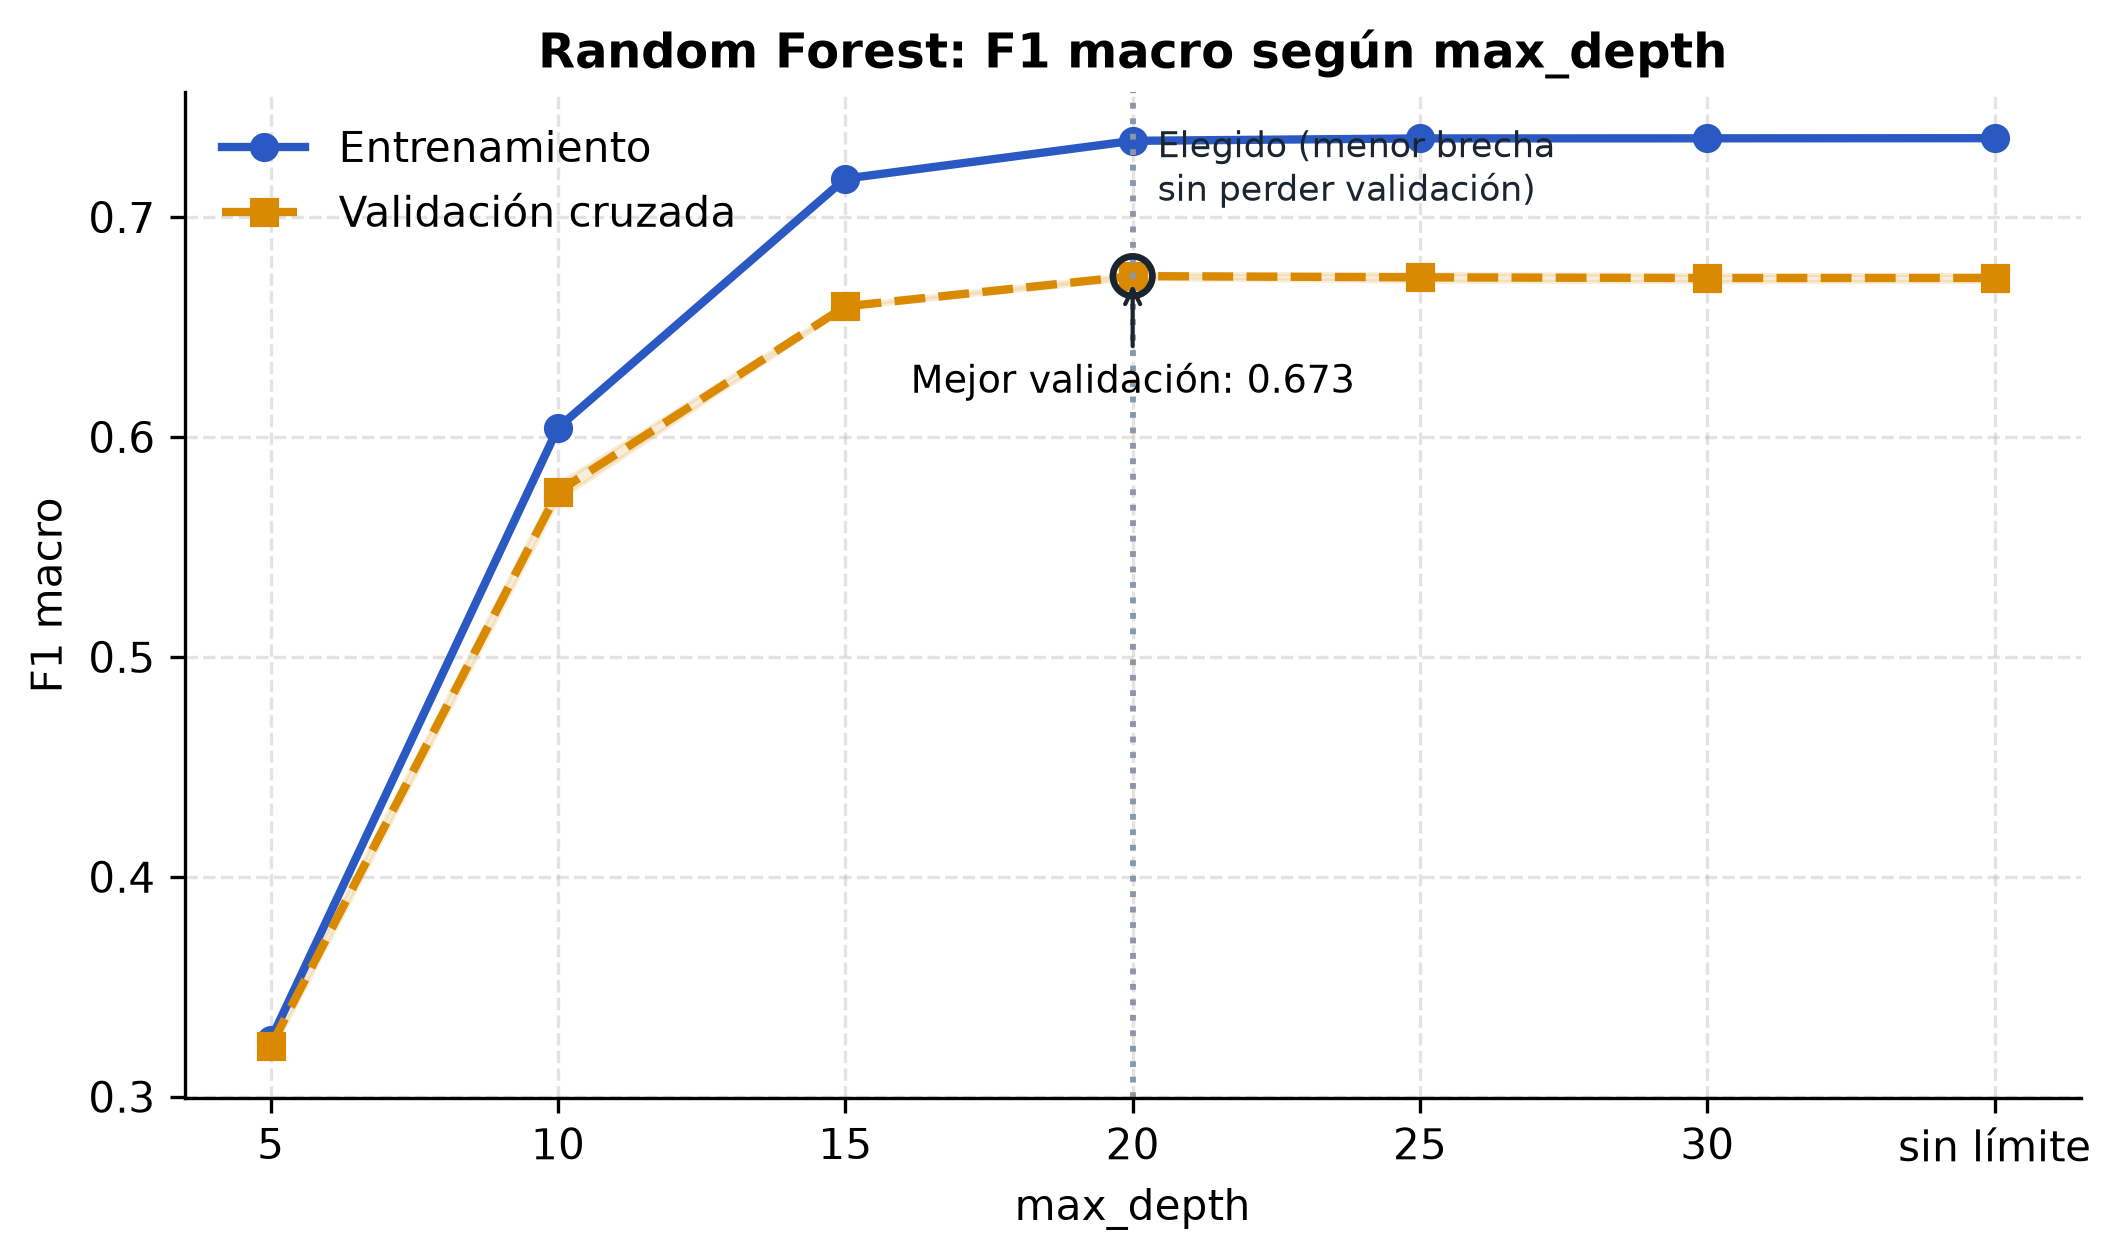

In [7]:
for f in ("C_curva_por_tamano.png", "D_curva_min_samples_leaf.png", "D_curva_max_depth.png"):
    display(Markdown(f"**Random Forest · {f[:-4]}**")); display(Image(filename=str(R / "random_forest" / f), width=640))

## 5. Análisis y diagnóstico detallado

In [8]:
print("Umbrales:", UMBRALES)
filas = []
for m in ("xgboost", "cnn1d", "transformer"):
    for momento in ("antes", "despues"):
        h = pd.read_csv(R / m / momento / "historial.csv")
        met = metricas_curvas(h); d, razones = diagnosticar(met)
        filas.append({"modelo": m, "momento": momento, "diagnostico": d, **met, "razones": "; ".join(razones)})
rf = json.loads((R / "random_forest/curvas.json").read_text())
filas.append({"modelo": "random_forest (curva C)", "momento": "antes", "diagnostico": rf["diagnostico"], **rf["metricas"],
              "razones": "; ".join(rf["razones"])})
diag = pd.DataFrame(filas); display(diag)

Umbrales: {'brecha_alta': 0.05, 'f1_bajo': 0.8, 'mejora_minima': 0.005, 'pendiente_minima': 0.002}


,modelo,momento,diagnostico,pasos,f1_entrenamiento,f1_validacion,mejor_f1_validacion,mejor_paso,mejor_es_ultimo,brecha_final,brecha_relativa,pendiente_val,pendiente_ent,mejora_final,razones,brecha_inicial
0,xgboost,antes,mixto,400.0,0.9825,0.8779,0.8779,391.0,True,0.1047,0.1065,-0.0006,-0.0029,0.0093,brecha final de 0.105 (mayor que 0.05); seguía...,NaN
1,xgboost,despues,mixto,400.0,0.9625,0.8729,0.8729,391.0,True,0.0895,0.0930,-0.0008,-0.0022,0.0115,brecha final de 0.089 (mayor que 0.05); seguía...,NaN
2,cnn1d,antes,subajuste,15.0,0.6216,0.6169,0.6169,15.0,True,0.0047,0.0076,-0.0192,-0.0216,0.0513,F1 de entrenamiento bajo (0.622 < 0.8) con bre...,NaN
3,cnn1d,despues,subajuste,40.0,0.7745,0.7576,0.7583,38.0,True,0.0169,0.0218,-0.0064,-0.0094,0.0172,F1 de entrenamiento bajo (0.774 < 0.8) con bre...,NaN
4,transformer,antes,subajuste,15.0,0.6645,0.6570,0.6570,15.0,True,0.0075,0.0113,-0.0321,-0.0369,0.0423,F1 de entrenamiento bajo (0.664 < 0.8) con bre...,NaN
5,transformer,despues,subajuste,25.0,0.7898,0.7692,0.7692,25.0,True,0.0205,0.0260,-0.0135,-0.0189,0.0272,F1 de entrenamiento bajo (0.790 < 0.8) con bre...,NaN
6,random_forest (curva C),antes,mixto,NaN,0.7367,0.6739,NaN,NaN,True,0.0628,0.0852,0.0000,0.0000,0.0226,brecha final de 0.063 (mayor que 0.05); seguía...,0.1031


**Interpretación** (calculada a partir de las métricas de cada curva, con el mismo módulo que usa el informe técnico)

In [9]:
from src.diagnostico.narrativa import analisis_red, analisis_rf, analisis_xgb
for red in ('cnn1d', 'transformer'):
    display(Markdown(f'**{red}.** ' + analisis_red(R, red)))
display(Markdown('**XGBoost.** ' + analisis_xgb(R)))
display(Markdown('**Random Forest.** ' + analisis_rf(rf)))

**cnn1d.** Antes de la estrategia, en 15 épocas, el mejor F1 de validación (0,617) se alcanzó en la época 15; al final, las curvas seguían subiendo, con una brecha de 0,005, y la pérdida de validación descendía en el tramo final. Después de la estrategia, en 40 épocas, el mejor F1 de validación (0,758) se alcanzó en la época 38; al final, las curvas seguían subiendo, con una brecha de 0,017, y la pérdida de validación descendía en el tramo final.

**transformer.** Antes de la estrategia, en 15 épocas, el mejor F1 de validación (0,657) se alcanzó en la época 15; al final, las curvas seguían subiendo, con una brecha de 0,007, y la pérdida de validación descendía en el tramo final. Después de la estrategia, en 25 épocas, el mejor F1 de validación (0,769) se alcanzó en la época 25; al final, las curvas seguían subiendo, con una brecha de 0,021, y la pérdida de validación descendía en el tramo final.

**XGBoost.** En el tramo final, la pérdida de entrenamiento sigue bajando mientras la de validación se aplana; la brecha final de F1 es 0,105 y el mejor punto de validación está en la ronda 391 de 400.

**Random Forest.** La curva por tamaño muestra que el F1 de validación pasa de 0,475 con 6 666 flujos a 0,674 con 66 666, y que en el último tramo sigue creciendo: más datos todavía ayudan. En la curva de min_samples_leaf, la mejor validación (0,818) se obtiene con 1, y la estrategia eligió 1. En la curva de max_depth, la mejor validación (0,673) se obtiene con 20, y la estrategia eligió 20. 

## 6. Implementación de estrategias de mejora

| Modelo | Diagnóstico | Estrategia |
|---|---|---|
| Random Forest | Subajuste | Ajuste de complejidad guiado por las curvas D (en la práctica, **más** complejidad) |
| CNN 1D y Transformer | Subajuste | Más épocas, tasa de aprendizaje **OneCycle** y **parada temprana** |
| XGBoost | Mixto | **Regularización**: submuestreo de filas y columnas 0,8, L2 = 5, min_child_weight = 5 |

In [10]:
for m in ("random_forest", "xgboost"):
    d = json.loads((R / m / "antes_despues.json").read_text())
    print(m, "→", d["estrategia"], "| parámetros después:", d["filas"][1].get("parametros"))

random_forest → Reducción de complejidad | parámetros después: {'n_estimators': 150, 'max_depth': 20, 'min_samples_leaf': 1, 'max_samples': 0.5, 'max_features': 'sqrt', 'n_jobs': -1}
xgboost → Regularización | parámetros después: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1, 'tree_method': 'hist', 'early_stopping_rounds': 30, 'n_jobs': -1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5.0, 'min_child_weight': 5}


## 7. Comparación antes/después de mejoras

,modelo,momento,diagnostico,f1_entrenamiento,f1_validacion,f1_prueba,brecha,mejor_paso,pasos,rondas,epocas_ejecutadas,tamano_MB,segundos
0,Random Forest,Antes,subajuste,0.7954,0.7468,0.7417,0.0486,NaN,NaN,NaN,NaN,53.53,5.8
1,Random Forest,Después,sobreajuste,0.9710,0.8506,0.8382,0.1204,NaN,NaN,NaN,NaN,119.73,6.9
2,XGBoost,Antes,mixto,0.9825,0.8779,0.8634,0.1047,391.0,400.0,400.0,NaN,66.95,1089.0
3,XGBoost,Después,mixto,0.9625,0.8729,0.8611,0.0895,391.0,400.0,400.0,NaN,51.05,934.9
4,CNN 1D,Antes,subajuste,0.6216,0.6169,0.6118,0.0047,15.0,15.0,NaN,15.0,NaN,287.1
5,CNN 1D,Después,subajuste,0.7745,0.7576,0.7456,0.0169,38.0,40.0,NaN,40.0,NaN,882.0
6,Transformer,Antes,subajuste,0.6645,0.6570,0.6447,0.0075,15.0,15.0,NaN,15.0,NaN,1450.9
7,Transformer,Después,subajuste,0.7898,0.7692,0.7570,0.0205,25.0,25.0,NaN,25.0,NaN,2580.9


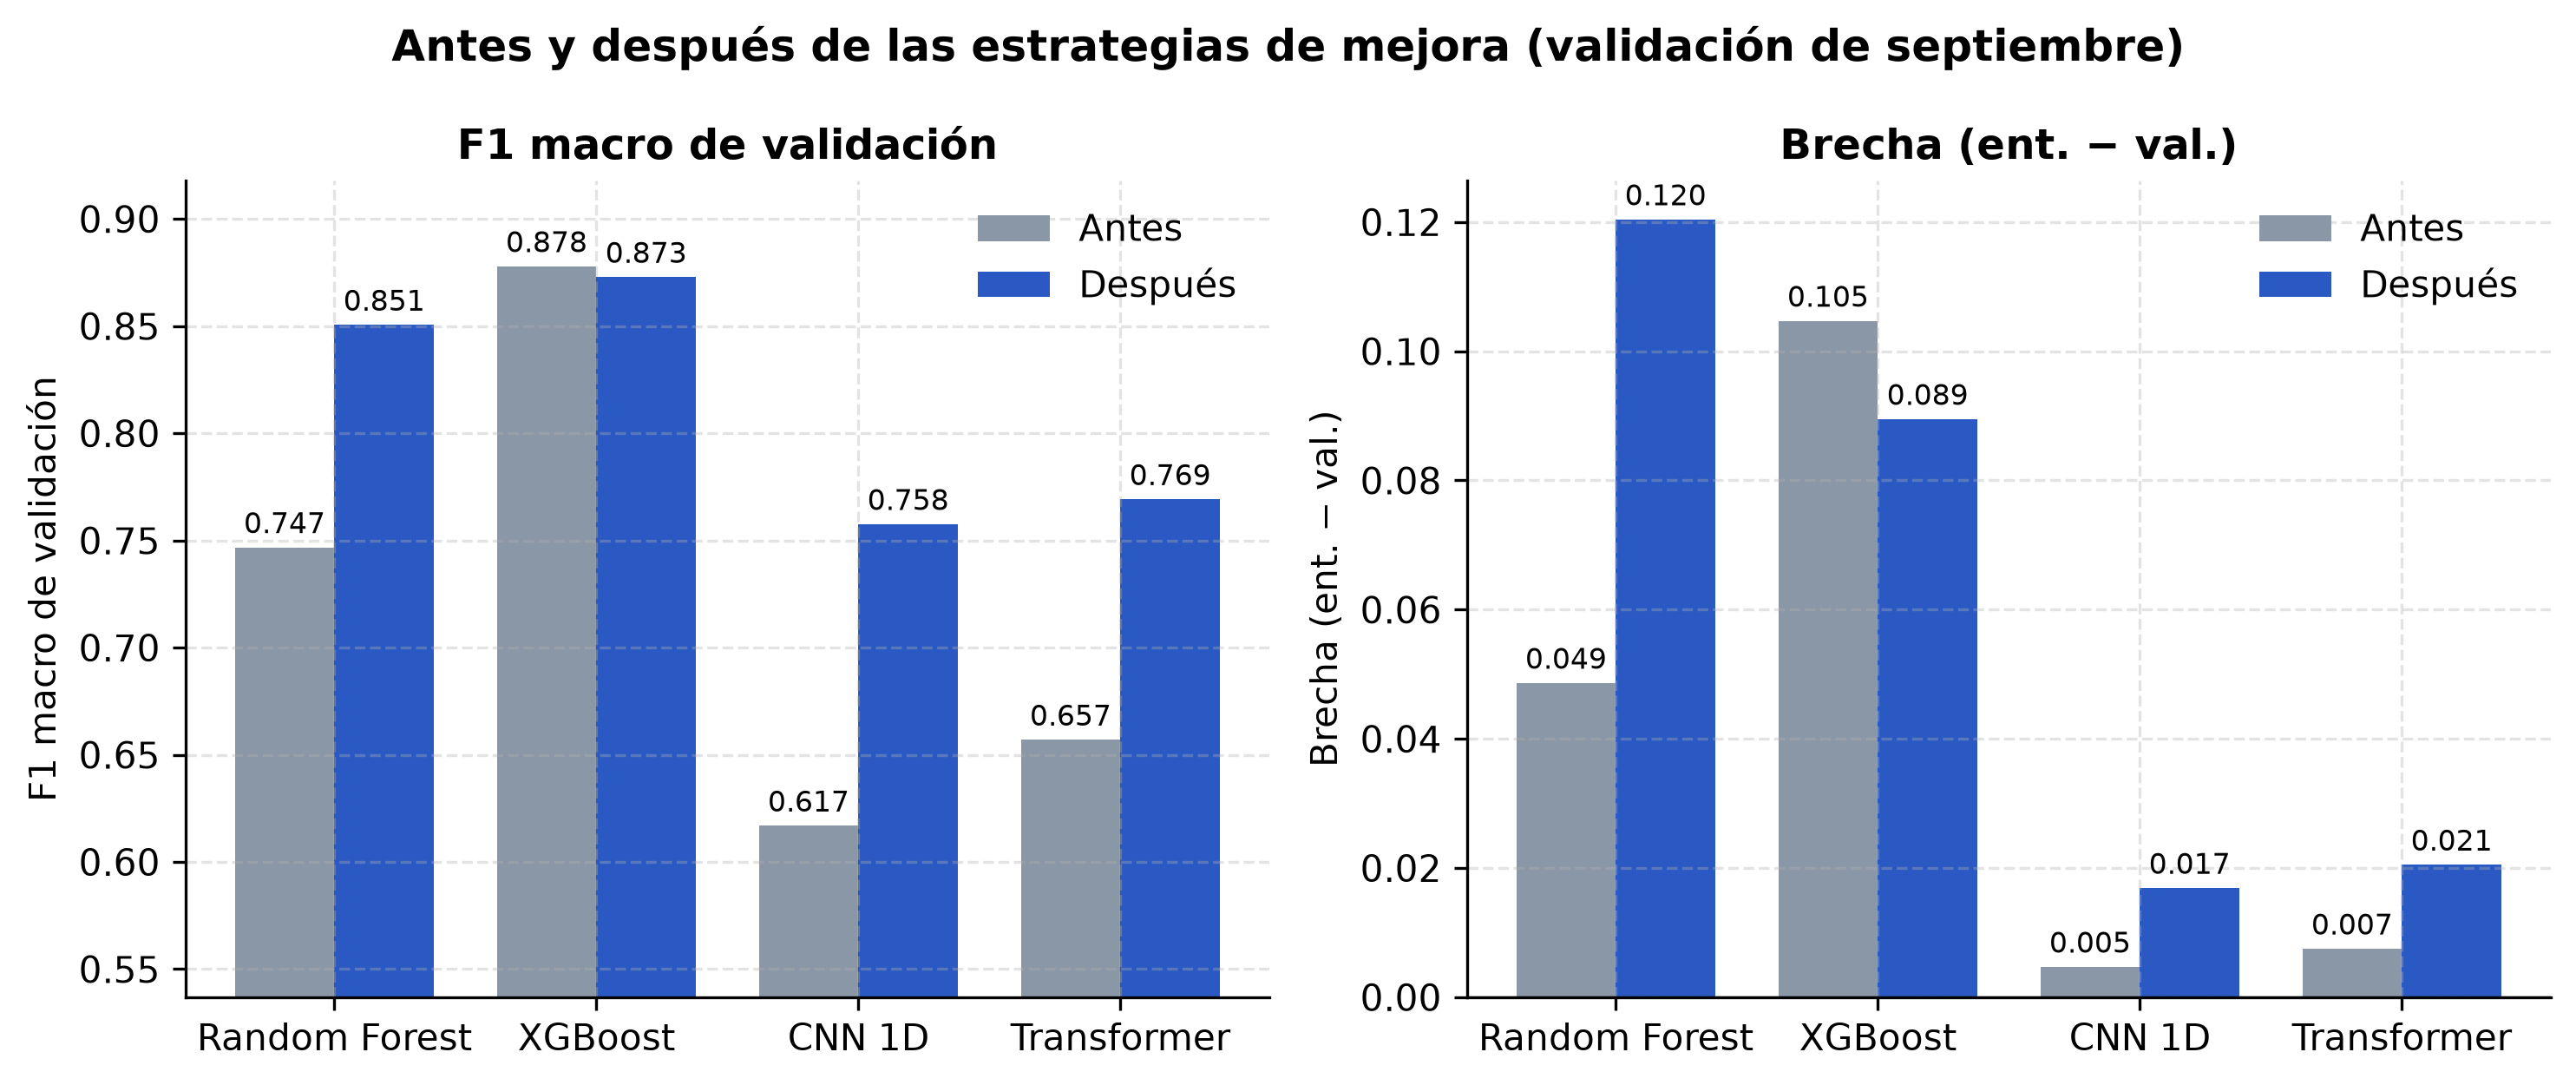

momento,Antes,Después,mejora_puntos
modelo,,,
CNN 1D,0.6118,0.7456,13.3756
Random Forest,0.7417,0.8382,9.6507
Transformer,0.6447,0.7570,11.2343
XGBoost,0.8634,0.8611,-0.2257


In [11]:
comp = pd.read_csv(R / "comparacion_antes_despues.csv"); display(comp)
display(Image(filename=str(R / "comparacion_antes_despues.png"), width=860))
piv = comp.pivot(index="modelo", columns="momento", values="f1_prueba")
piv["mejora_puntos"] = (piv["Después"] - piv["Antes"]) * 100; display(piv.round(4))

## 8. Conclusiones y reflexiones
1. **El problema dominante era el subajuste, no el sobreajuste.** Las estrategias subieron el F1 macro de
   **prueba** (octubre, datos no vistos) en Random Forest, la CNN 1D y el Transformer; la columna `mejora_puntos` de la
   sección 7 da el valor exacto de cada mejora.
2. **La brecha no es el objetivo.** En Random Forest pasó de 0,049 a 0,120 y el modelo generaliza mucho mejor: una brecha pequeña
   puede indicar un modelo igual de deficiente en ambos conjuntos.
3. **XGBoost:** la regularización redujo la brecha (0,105 → 0,090) con −0,2 puntos de F1 y un modelo 24 % más liviano.
4. **Las redes siguen en subajuste** tras la estrategia (mejor época al final): conviene entrenar hasta que actúe la parada temprana.
5. **Reflexión metodológica:** diagnosticar solo con validación y usar la prueba una vez evitó ajustar las decisiones a octubre.
   Siguiente paso: repetir con los 640 000 flujos y actualizar la comparación del proyecto y la aplicación web.